## Etape 1 : Définition du projet

### Projet 3 - Prédisez la consommation d'énergie des bâtiments

### Viken KHATCHERIAN

### formation AI Engineer - OpenClassrooms


## Etape 2 : Chargement et compréhension des données

In [53]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Chargement du dataset
df_2016beb = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [55]:
# Nombre de lignes et de colonnes du dataframe obtenu
df_2016beb.shape

(3376, 46)

In [56]:
# Identification du type des colonnes et du nombre de valeurs non nulles
df_2016beb.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [57]:
# Liste des colonnes retenues
cols_pertinentes = [
    # Label
    "SiteEUIWN(kBtu/sf)",  
    
    # Structure
    "YearBuilt",
    "NumberofFloors",
    "NumberofBuildings",
    "PropertyGFATotal",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    
    # Usage
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    
    # Localisation
    "Neighborhood",
    "CouncilDistrictCode"
]

# Sélection du sous-dataframe
df_2016beb_rel = df_2016beb[cols_pertinentes]

# Réaffichage du type et du nombre de valeurs non nulles des colonnes retenues
df_2016beb_rel.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   SiteEUIWN(kBtu/sf)               3370 non-null   float64
 1   YearBuilt                        3376 non-null   int64  
 2   NumberofFloors                   3376 non-null   int64  
 3   NumberofBuildings                3368 non-null   float64
 4   PropertyGFATotal                 3376 non-null   int64  
 5   PropertyGFABuilding(s)           3376 non-null   int64  
 6   PropertyGFAParking               3376 non-null   int64  
 7   BuildingType                     3376 non-null   str    
 8   PrimaryPropertyType              3376 non-null   str    
 9   LargestPropertyUseType           3356 non-null   str    
 10  LargestPropertyUseTypeGFA        3356 non-null   float64
 11  SecondLargestPropertyUseType     1679 non-null   str    
 12  SecondLargestPropertyUseTypeGFA

In [58]:
# statistiques descriptives générales du dataframe
df_2016beb_rel.describe()

,SiteEUIWN(kBtu/sf),YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,PropertyGFABuilding(s),PropertyGFAParking,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode
count,3370.000000,3376.000000,3376.000000,3368.000000,3.376000e+03,3.376000e+03,3376.000000,3.356000e+03,1679.000000,596.000000,3376.000000
mean,57.033798,1968.573164,4.709123,1.106888,9.483354e+04,8.683201e+04,8001.526066,7.917764e+04,28444.075817,11738.675166,4.439277
std,57.163330,33.088156,5.494465,2.108402,2.188376e+05,2.079398e+05,32326.723928,2.017034e+05,54392.917928,29331.199286,2.120625
min,0.000000,1900.000000,0.000000,0.000000,1.128500e+04,3.636000e+03,0.000000,5.656000e+03,0.000000,0.000000,1.000000
25%,29.400000,1948.000000,2.000000,1.000000,2.848700e+04,2.775600e+04,0.000000,2.509475e+04,5000.000000,2239.000000,3.000000
50%,40.900002,1975.000000,4.000000,1.000000,4.417500e+04,4.321600e+04,0.000000,3.989400e+04,10664.000000,5043.000000,4.000000
75%,64.275002,1997.000000,5.000000,1.000000,9.099200e+04,8.427625e+04,0.000000,7.620025e+04,26640.000000,10138.750000,7.000000
max,834.400024,2015.000000,99.000000,111.000000,9.320156e+06,9.320156e+06,512608.000000,9.320156e+06,686750.000000,459748.000000,7.000000


Constat d'ordres de grandeur différents entre les colonnes numériques

In [59]:
# Analyse des valeurs manquantes
missing = df_2016beb_rel.isnull().sum().sort_values(ascending=False)
missing_percent = (df_2016beb_rel.isnull().sum() / len(df_2016beb_rel)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values("Percentage", ascending=False)

missing_df.head(20)

,Missing Values,Percentage
ThirdLargestPropertyUseType,2780,82.345972
ThirdLargestPropertyUseTypeGFA,2780,82.345972
SecondLargestPropertyUseType,1697,50.266588
SecondLargestPropertyUseTypeGFA,1697,50.266588
LargestPropertyUseType,20,0.592417
LargestPropertyUseTypeGFA,20,0.592417
NumberofBuildings,8,0.236967
SiteEUIWN(kBtu/sf),6,0.177725
BuildingType,0,0.000000
PropertyGFABuilding(s),0,0.000000


### Colonnes avec plus de 50% de valeurs manquantes
- ThirdLargestPropertyUseType
- ThirdLargestPropertyUseTypeGFA

### Colonnes critiques
-  SecondLargestPropertyUseType
-  SecondLargestPropertyUseTypeGFA

In [60]:
# Analyse des doublons
df_2016beb_rel.duplicated().sum()


np.int64(0)

In [61]:
df_2016beb_rel[df_2016beb_rel.duplicated()]

,SiteEUIWN(kBtu/sf),YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,PropertyGFABuilding(s),PropertyGFAParking,BuildingType,PrimaryPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,Neighborhood,CouncilDistrictCode


Absence de doublons dans les colonnes retenues

In [62]:
# Analyse des types de variables
# Analyse des types de variables
numeric_cols = df_2016beb_rel.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_2016beb_rel.select_dtypes(include=["object", "category", "string"]).columns

# Colonnes numériques
print(f"Colonnes numériques ({len(numeric_cols)}) :")
for col in numeric_cols:
    print(f"- {col}")

print("\nColonnes catégorielles :")

# Colonnes catégorielles avec nombre de modalités
for col in categorical_cols:
    n_modalites = df_2016beb_rel[col].nunique()
    print(f"- {col} ({n_modalites} modalités)")

Colonnes numériques (11) :
- SiteEUIWN(kBtu/sf)
- YearBuilt
- NumberofFloors
- NumberofBuildings
- PropertyGFATotal
- PropertyGFABuilding(s)
- PropertyGFAParking
- LargestPropertyUseTypeGFA
- SecondLargestPropertyUseTypeGFA
- ThirdLargestPropertyUseTypeGFA
- CouncilDistrictCode

Colonnes catégorielles :
- BuildingType (8 modalités)
- PrimaryPropertyType (24 modalités)
- LargestPropertyUseType (56 modalités)
- SecondLargestPropertyUseType (50 modalités)
- ThirdLargestPropertyUseType (44 modalités)
- Neighborhood (19 modalités)


Identifier, lors de l’EDA (étape 3), les modalités rares dans les variables catégorielles afin de réduire la cardinalité avant l’encodage (One-Hot Encoding). 

Cela permet de limiter l’explosion du nombre de variables et de vérifier la règle empirique selon laquelle le nombre d’observations doit être largement supérieur au nombre total de variables explicatives (features), afin de réduire les risques liés à la malédiction de la dimensionnalité.

# Etape 3 : Analyse Exploratoire et Approfondie (EDA)

In [63]:
# Traitement des valeurs manquantes
# Supprimer les lignes avec la valeur cible manquante
df_2016beb_rel = df_2016beb_rel.dropna(subset=["SiteEUIWN(kBtu/sf)"])
df_2016beb_rel.shape

(3370, 17)

In [64]:
# Imputer le faible nombre de valeurs manquantes de LargestPropertyUseType par la modalité la plus fréquente
mode_largest = df_2016beb_rel['LargestPropertyUseType'].mode()[0]
df_2016beb_rel['LargestPropertyUseType'] = df_2016beb_rel['LargestPropertyUseType'].fillna(mode_largest)
median_largest_gfa = df_2016beb_rel['LargestPropertyUseTypeGFA'].median()
df_2016beb_rel['LargestPropertyUseTypeGFA'] = df_2016beb_rel['LargestPropertyUseTypeGFA'].fillna(median_largest_gfa)
df_2016beb_rel.shape

(3370, 17)

In [65]:
# SecondLargestPropertyUseType et GFA avec Unknown et 0 respectivement
df_2016beb_rel['SecondLargestPropertyUseType'] = df_2016beb_rel['SecondLargestPropertyUseType'].fillna('Unknown')
df_2016beb_rel['SecondLargestPropertyUseTypeGFA'] = df_2016beb_rel['SecondLargestPropertyUseTypeGFA'].fillna(0)
df_2016beb_rel.shape

(3370, 17)

In [66]:
# Suppression des colonnes ThirdLargestPropertyUseType et GFA car trop de valeurs manquantes
df_2016beb_rel = df_2016beb_rel.drop(columns=['ThirdLargestPropertyUseType','ThirdLargestPropertyUseTypeGFA'])
df_2016beb_rel.shape

(3370, 15)

In [67]:
# Imputer la médiane pour les quelques valeurs manquantes de la colonne NumberofBuildings 
median_buildings = df_2016beb_rel['NumberofBuildings'].median()
df_2016beb_rel['NumberofBuildings'] = df_2016beb_rel['NumberofBuildings'].fillna(median_buildings)
df_2016beb_rel.shape

(3370, 15)

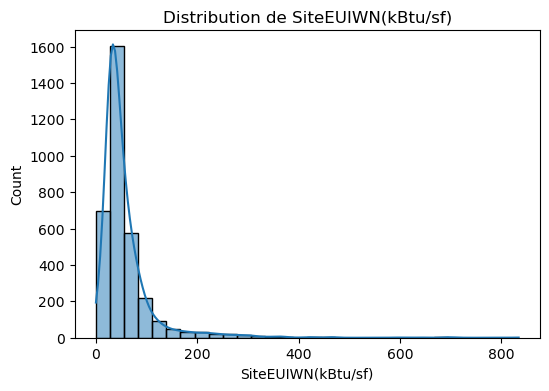

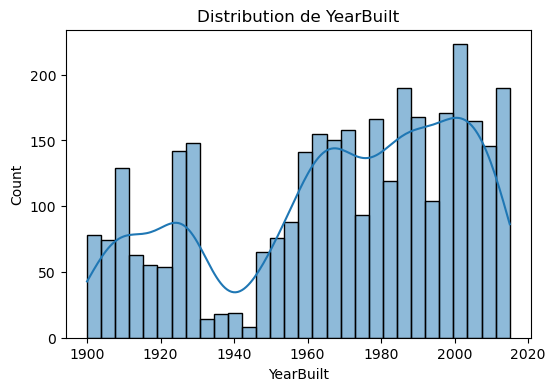

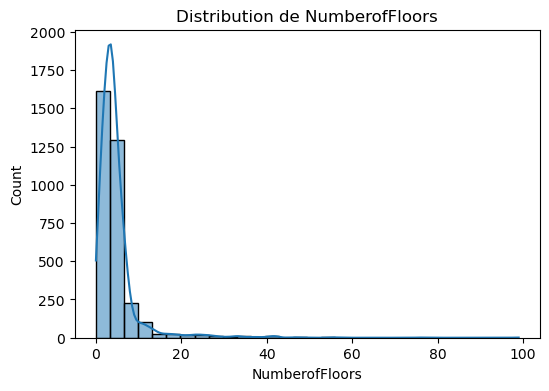

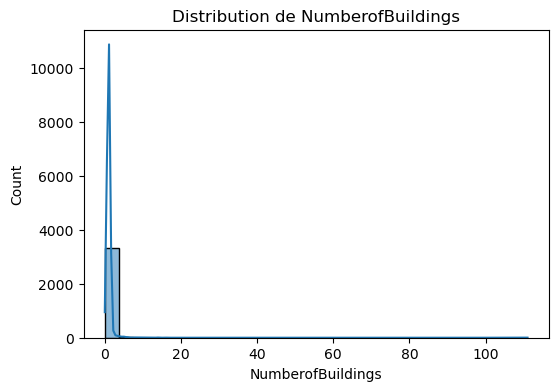

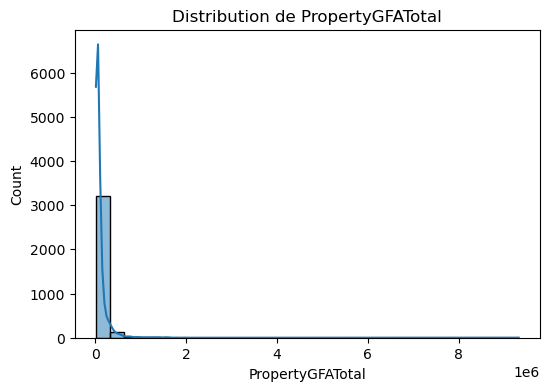

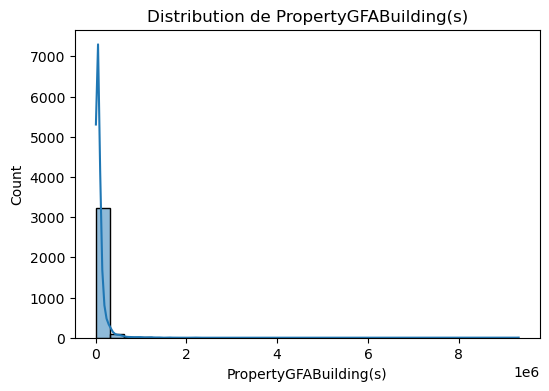

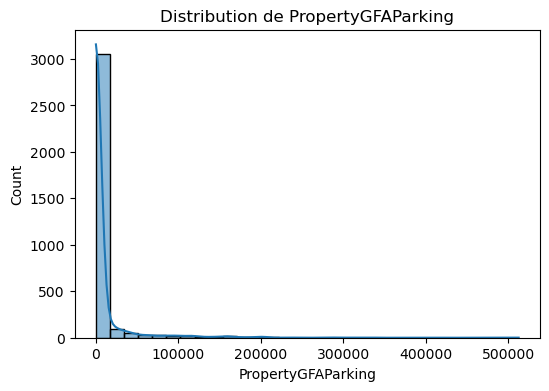

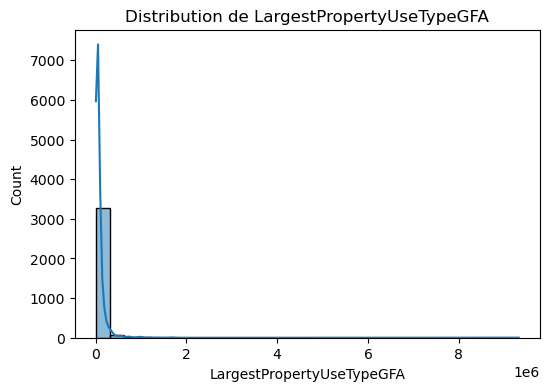

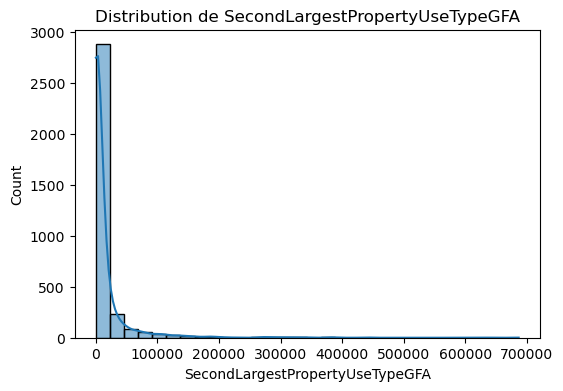

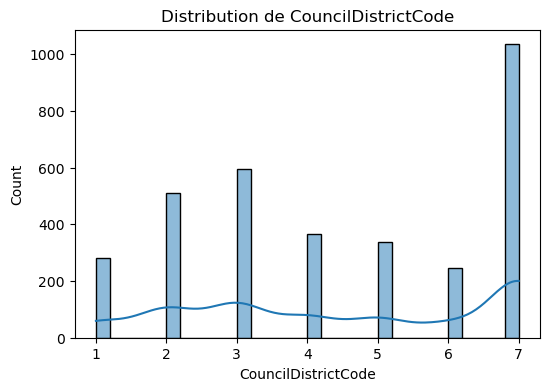

In [68]:
# Analyse des distributions des variables numériques
numeric_cols = df_2016beb_rel.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_2016beb_rel[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")
    plt.show()

In [69]:
# Statistiques descriptives de SiteEUIWN (kBtu/sf)
df_2016beb_rel["SiteEUIWN(kBtu/sf)"].describe()

count    3370.000000
mean       57.033798
std        57.163330
min         0.000000
25%        29.400000
50%        40.900002
75%        64.275002
max       834.400024
Name: SiteEUIWN(kBtu/sf), dtype: float64

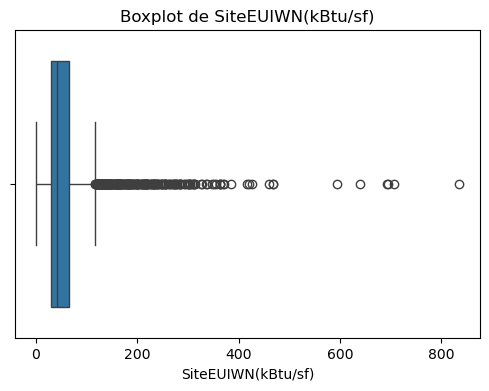

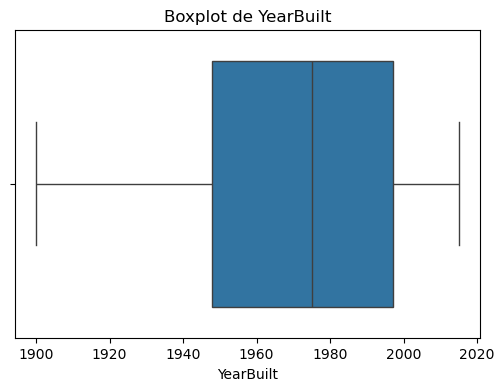

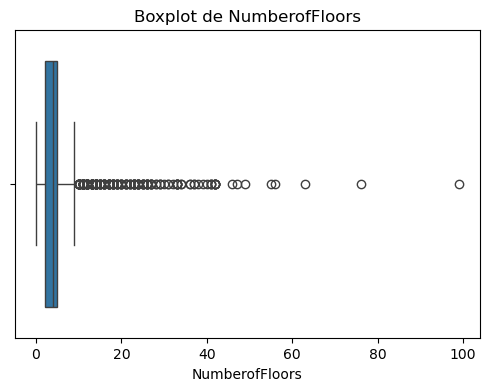

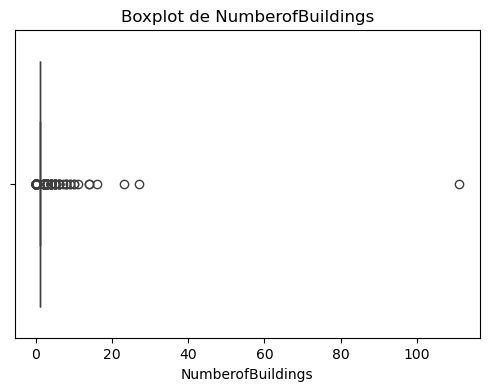

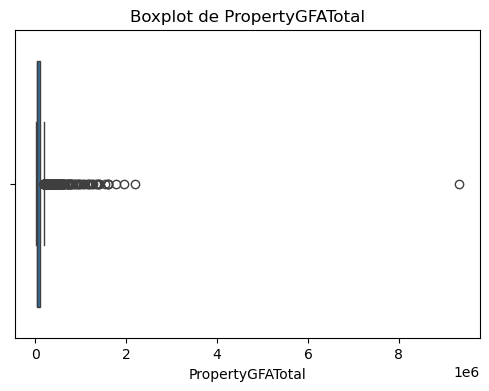

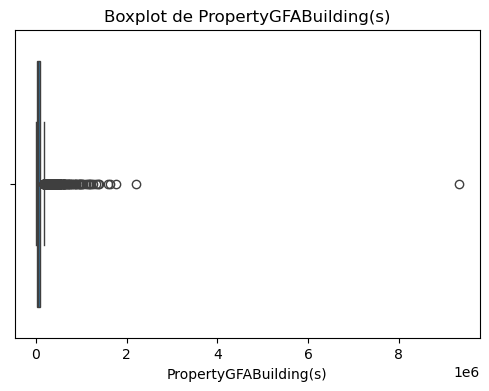

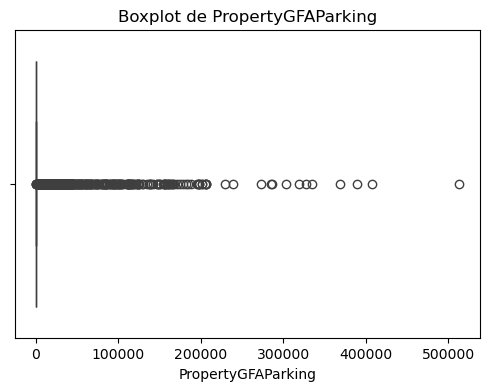

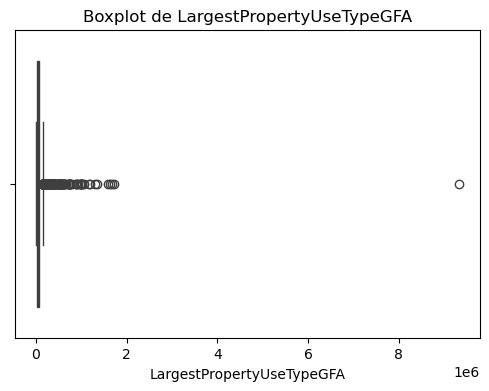

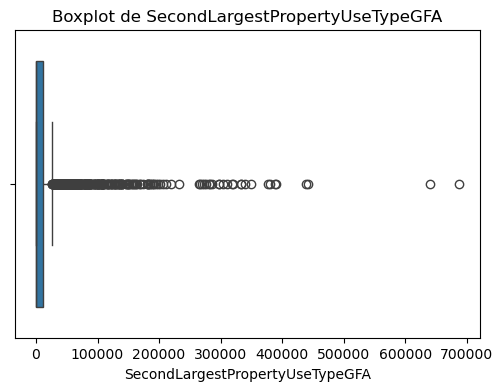

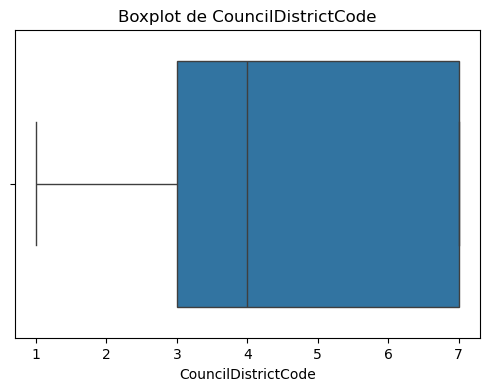

In [70]:
# Boxplots pour détecter des outliers
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_2016beb_rel[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [71]:
# Analyse des variables catégorielles
categorical_cols = df_2016beb_rel.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"{col} ({df_2016beb_rel[col].nunique()} modalités)")
    display(df_2016beb_rel[col].value_counts().head(10))

BuildingType (8 modalités)


BuildingType
NonResidential          1457
Multifamily LR (1-4)    1015
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

PrimaryPropertyType (24 modalités)


PrimaryPropertyType
Low-Rise Multifamily           984
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    292
Other                          256
Warehouse                      187
Large Office                   172
K-12 School                    139
Mixed Use Property             132
High-Rise Multifamily          105
Retail Store                    91
Name: count, dtype: int64

LargestPropertyUseType (56 modalités)


LargestPropertyUseType
Multifamily Housing           1682
Office                         497
Non-Refrigerated Warehouse     199
K-12 School                    139
Other                          102
Retail Store                    99
Hotel                           77
Worship Facility                71
Distribution Center             54
Senior Care Community           46
Name: count, dtype: int64

SecondLargestPropertyUseType (51 modalités)


SecondLargestPropertyUseType
Unknown                           1692
Parking                            976
Office                             215
Retail Store                       154
Other                               59
Restaurant                          40
Non-Refrigerated Warehouse          33
Multifamily Housing                 18
Fitness Center/Health Club/Gym      17
Supermarket/Grocery Store           14
Name: count, dtype: int64

Neighborhood (19 modalités)


Neighborhood
DOWNTOWN                 571
EAST                     453
MAGNOLIA / QUEEN ANNE    422
GREATER DUWAMISH         375
NORTHEAST                278
LAKE UNION               251
NORTHWEST                209
SOUTHWEST                166
NORTH                    145
BALLARD                  126
Name: count, dtype: int64

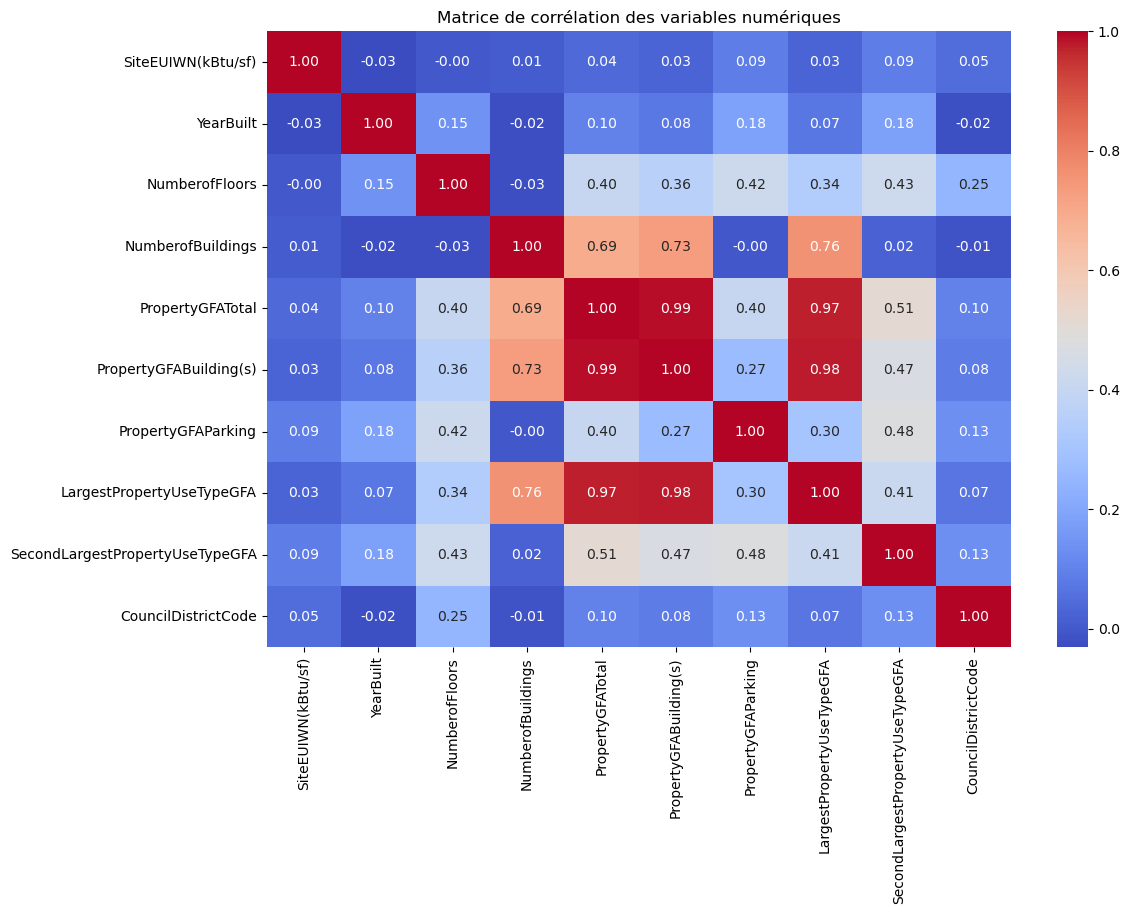

In [72]:
# recherche de corrélations entre variables numériques
plt.figure(figsize=(12,8))
corr_matrix = df_2016beb_rel[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

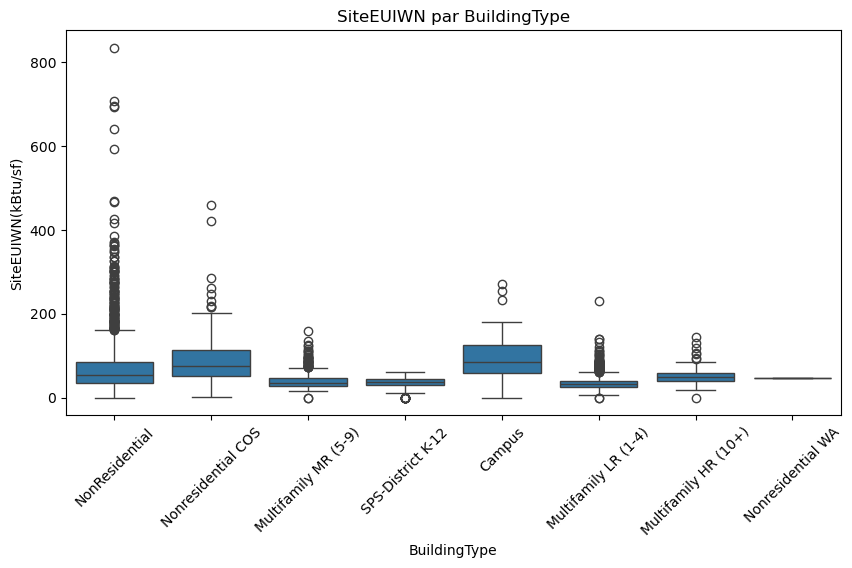

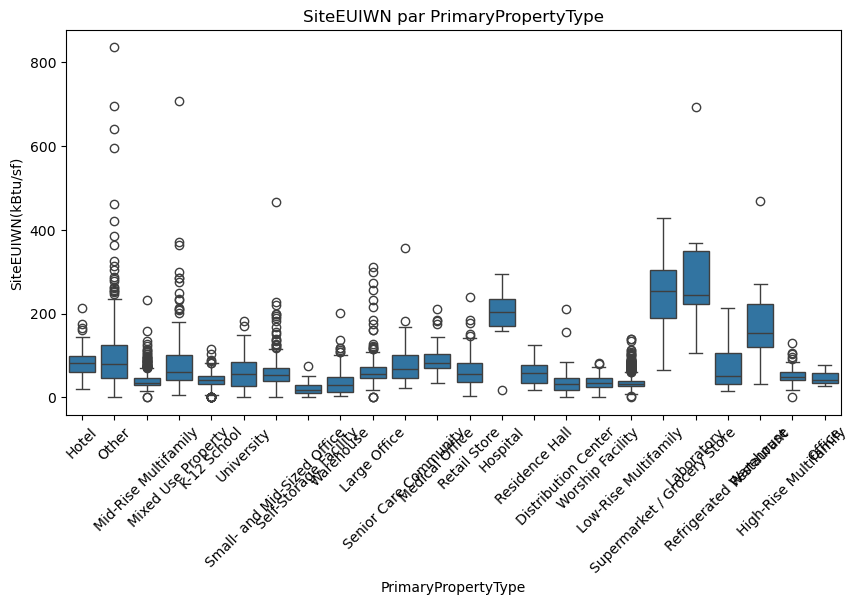

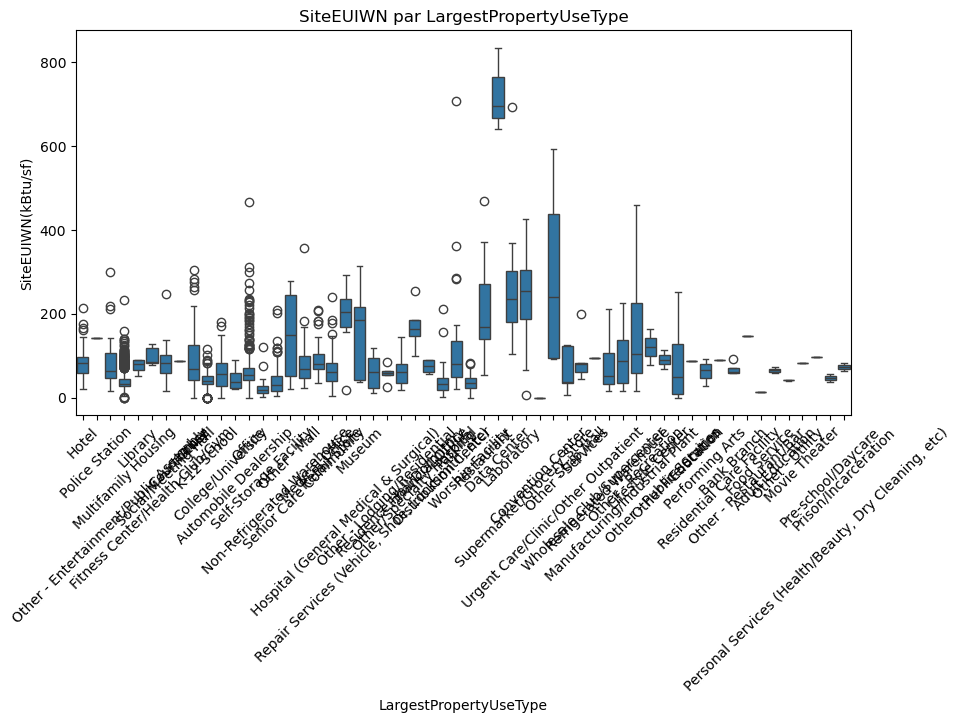

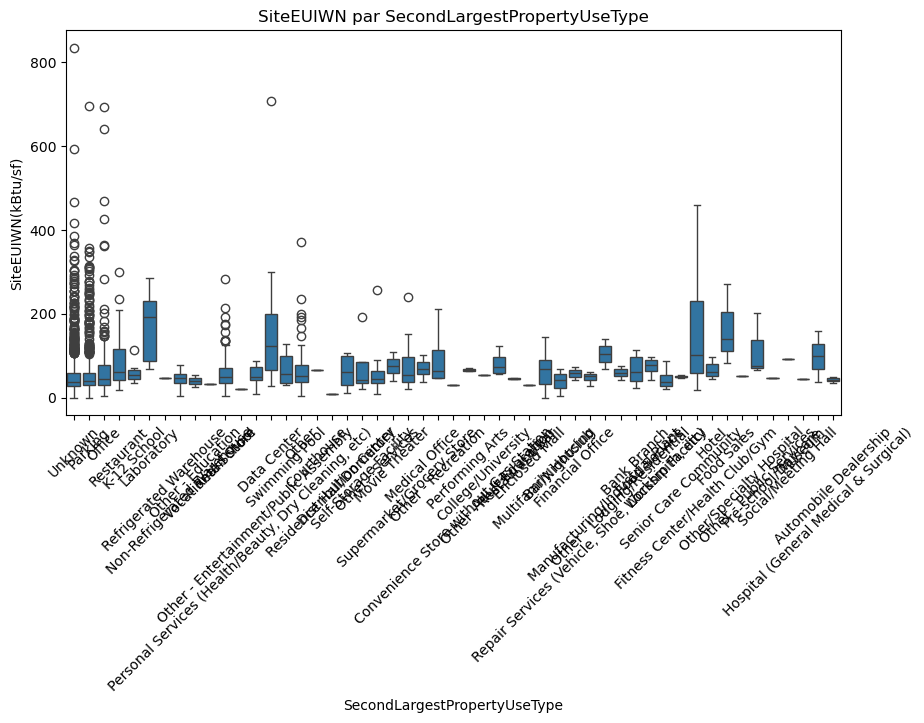

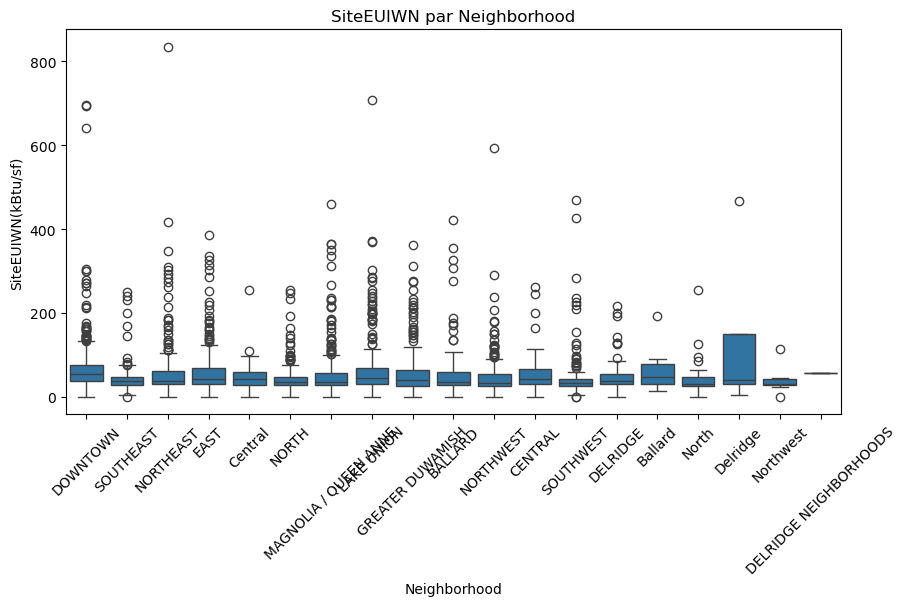

In [73]:
# Recherche de relations entre variable cible et features catégorielles
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df_2016beb_rel[col], y=df_2016beb_rel['SiteEUIWN(kBtu/sf)'])
    plt.xticks(rotation=45)
    plt.title(f"SiteEUIWN par {col}")
    plt.show()

In [74]:
# Statistiques descriptives des variables numériques avec skewness et kurtosis
stats = df_2016beb_rel[numeric_cols].describe().T
stats["skew"] = df_2016beb_rel[numeric_cols].skew()
stats["kurtosis"] = df_2016beb_rel[numeric_cols].kurtosis()

display(stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
SiteEUIWN(kBtu/sf),3370.0,57.033798,57.163330,0.0,29.4,40.900002,64.275002,8.344000e+02,4.827518,37.639503
YearBuilt,3370.0,1968.590208,33.098040,1900.0,1948.0,1975.000000,1997.000000,2.015000e+03,-0.540266,-0.870682
NumberofFloors,3370.0,4.710386,5.498896,0.0,2.0,4.000000,5.000000,9.900000e+01,5.917898,55.860218
NumberofBuildings,3370.0,1.106825,2.107777,0.0,1.0,1.000000,1.000000,1.110000e+02,43.407857,2206.604101
PropertyGFATotal,3370.0,94912.939169,219018.184812,11285.0,28494.0,44195.000000,91058.000000,9.320156e+06,24.111613,944.765764
PropertyGFABuilding(s),3370.0,86925.562018,208112.061350,3636.0,27774.5,43225.000000,84388.000000,9.320156e+06,27.603646,1159.530971
PropertyGFAParking,3370.0,7987.377151,32325.562319,0.0,0.0,0.000000,0.000000,5.126080e+05,6.660732,59.095365
LargestPropertyUseTypeGFA,3370.0,78990.571810,201299.619963,5656.0,25131.0,39888.000000,75448.750000,9.320156e+06,30.154283,1325.819764
SecondLargestPropertyUseTypeGFA,3370.0,14168.175162,40938.572941,0.0,0.0,0.000000,10622.750000,6.867500e+05,6.797313,66.762488
CouncilDistrictCode,3370.0,4.436795,2.120938,1.0,3.0,4.000000,7.000000,7.000000e+00,-0.068416,-1.445349


In [75]:
# Résumé numérique des variables catégorielles
df_2016beb_rel[categorical_cols].describe().T

,count,unique,top,freq
BuildingType,3370,8,NonResidential,1457
PrimaryPropertyType,3370,24,Low-Rise Multifamily,984
LargestPropertyUseType,3370,56,Multifamily Housing,1682
SecondLargestPropertyUseType,3370,51,Unknown,1692
Neighborhood,3370,19,DOWNTOWN,571


In [76]:
# Affichage des modalités les plus fréquentes pour les variables catégorielles
for col in categorical_cols:
    print(col)
    print(df_2016beb_rel[col].value_counts(normalize=True).head(10))

BuildingType
BuildingType
NonResidential          0.432344
Multifamily LR (1-4)    0.301187
Multifamily MR (5-9)    0.172107
Multifamily HR (10+)    0.032641
SPS-District K-12       0.029080
Nonresidential COS      0.025223
Campus                  0.007122
Nonresidential WA       0.000297
Name: proportion, dtype: float64
PrimaryPropertyType
PrimaryPropertyType
Low-Rise Multifamily           0.291988
Mid-Rise Multifamily           0.167359
Small- and Mid-Sized Office    0.086647
Other                          0.075964
Warehouse                      0.055490
Large Office                   0.051039
K-12 School                    0.041246
Mixed Use Property             0.039169
High-Rise Multifamily          0.031157
Retail Store                   0.027003
Name: proportion, dtype: float64
LargestPropertyUseType
LargestPropertyUseType
Multifamily Housing           0.499110
Office                        0.147478
Non-Refrigerated Warehouse    0.059050
K-12 School                   0.041246
Ot

In [77]:
# Identification de possibles corrélations avec la variable cible
target = "SiteEUIWN(kBtu/sf)"

corr_target = df_2016beb_rel[numeric_cols].corr()[target].sort_values(ascending=False)

display(corr_target)

corr_target.abs().sort_values(ascending=False)

SiteEUIWN(kBtu/sf)                 1.000000
PropertyGFAParking                 0.089160
SecondLargestPropertyUseTypeGFA    0.087800
CouncilDistrictCode                0.046414
PropertyGFATotal                   0.040080
PropertyGFABuilding(s)             0.028332
LargestPropertyUseTypeGFA          0.026860
NumberofBuildings                  0.007055
NumberofFloors                    -0.000857
YearBuilt                         -0.030900
Name: SiteEUIWN(kBtu/sf), dtype: float64

SiteEUIWN(kBtu/sf)                 1.000000
PropertyGFAParking                 0.089160
SecondLargestPropertyUseTypeGFA    0.087800
CouncilDistrictCode                0.046414
PropertyGFATotal                   0.040080
YearBuilt                          0.030900
PropertyGFABuilding(s)             0.028332
LargestPropertyUseTypeGFA          0.026860
NumberofBuildings                  0.007055
NumberofFloors                     0.000857
Name: SiteEUIWN(kBtu/sf), dtype: float64

In [78]:
# Détection numérique des outliers 
outliers = {}

for col in numeric_cols:
    Q1 = df_2016beb_rel[col].quantile(0.25)
    Q3 = df_2016beb_rel[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df_2016beb_rel[col] < lower) | (df_2016beb_rel[col] > upper)).sum()
    
    outliers[col] = n_outliers

pd.Series(outliers).sort_values(ascending=False)

PropertyGFAParking                 502
SecondLargestPropertyUseTypeGFA    422
PropertyGFATotal                   370
LargestPropertyUseTypeGFA          364
PropertyGFABuilding(s)             344
SiteEUIWN(kBtu/sf)                 251
NumberofFloors                     240
NumberofBuildings                  193
YearBuilt                            0
CouncilDistrictCode                  0
dtype: int64

In [79]:
# Identification de possibles relations entre variables catégorielles et la variable cible
for col in categorical_cols:
    print(f"\n{col}")
    display(df_2016beb_rel.groupby(col)['SiteEUIWN(kBtu/sf)'].agg(['count','mean','median','std']).sort_values("mean", ascending=False))


BuildingType


,count,mean,median,std
BuildingType,,,,
Campus,24,106.762500,85.199997,69.750487
Nonresidential COS,85,99.500000,76.699997,80.073070
NonResidential,1457,75.269732,54.599998,76.206288
Multifamily HR (10+),110,53.392727,49.600000,21.267991
Nonresidential WA,1,46.200001,46.200001,NaN
Multifamily MR (5-9),580,41.237759,36.000000,18.850705
Multifamily LR (1-4),1015,37.690837,31.799999,18.543821
SPS-District K-12,98,34.924490,38.000000,16.925008



PrimaryPropertyType


,count,mean,median,std
PrimaryPropertyType,,,,
Laboratory,10,297.509998,244.849998,159.398346
Supermarket / Grocery Store,40,243.087501,254.400002,88.855474
Hospital,10,192.680001,203.900002,73.307388
Restaurant,12,176.725002,154.650002,119.544169
Other,256,105.398437,80.250000,106.663660
Medical Office,39,90.997436,81.300003,41.240402
Mixed Use Property,132,90.218182,60.650000,89.584603
Senior Care Community,45,83.648889,68.300003,56.259420
Hotel,77,83.422078,82.199997,34.488078



LargestPropertyUseType


,count,mean,median,std
LargestPropertyUseType,,,,
Data Center,3,722.966675,694.700012,100.332182
Urgent Care/Clinic/Other Outpatient,4,291.499994,240.350002,244.002874
Laboratory,13,263.438460,235.899994,152.990587
Supermarket/Grocery Store,41,238.809757,254.199997,93.383701
Restaurant,12,206.458334,167.199997,121.636133
Hospital (General Medical & Surgical),10,192.680001,203.900002,73.307388
Other/Specialty Hospital,4,169.399998,162.750000,64.027024
Museum,5,158.520002,184.699997,119.074528
Other - Recreation,31,150.729032,103.199997,121.801791



SecondLargestPropertyUseType


,count,mean,median,std
SecondLargestPropertyUseType,,,,
Data Center,13,171.346154,123.699997,180.481454
Laboratory,8,171.000000,191.649994,82.841624
Food Sales,3,163.900004,139.300003,96.774120
Fitness Center/Health Club/Gym,17,154.564707,101.000000,132.869519
Other - Public Services,3,113.600001,74.300003,76.086597
Manufacturing/Industrial Plant,2,103.900002,103.900002,50.770269
Hospital (General Medical & Surgical),2,98.099998,98.099998,87.115553
Other - Recreation,4,96.799998,64.250000,78.872764
Social/Meeting Hall,1,93.199997,93.199997,NaN



Neighborhood


,count,mean,median,std
Neighborhood,,,,
Delridge,4,137.850000,40.400000,220.125320
LAKE UNION,251,68.786853,43.900002,74.489143
Ballard,7,67.042857,47.500000,61.191281
DOWNTOWN,571,66.730298,54.500000,60.964625
NORTHEAST,278,59.291727,37.650000,73.097707
BALLARD,126,58.213492,36.549999,66.582578
EAST,453,57.455850,42.799999,46.251640
DELRIDGE NEIGHBORHOODS,1,56.200001,56.200001,NaN
CENTRAL,107,53.457944,42.900002,40.703890


### Analyse EDA
La distribution de la variable cible est: 
- très asymétrique à droite
- avec quelques valeurs extrêmement élevées
- présence probable d’outliers énergétiques

Cela signifie :
- certains bâtiments consomment beaucoup plus que la majorité
- les modèles linéaires peuvent être déstabilisés par ces valeurs

Appliquer à l'étape 4 (Feature engineering) une transformation logarithmique de la target pour :
- réduire l’effet des outliers
- stabiliser la variance

Plusieurs variables explicatives présentent :
- skewness très élevée
- kurtosis très élevée
- exemples : PropertyGFATotal, PropertyGFABuilding(s), LargestPropertyUseTypeGFA, NumberofBuildings

Les surfaces de bâtiments suivent une distribution log-normale :
- beaucoup de petits bâtiments
- quelques très grands complexes

Envisager à l'étape 4 (Feature Engineering) une transformation logarithmique de ces variables explicatives.

Aucune variable explicative numérique n’a de corrélation linéaire forte avec la target ce qui signifie:
- relation non linéaire
- dépendance du type d’usage du bâtiment
- interactions entre variables

Les modèles capables de capter cela :
- Random Forest
- Gradient Boosting
- XGBoost

Les outliers identifiés sont probablement réels;
- PropertyGFAParking	502
- SecondLargestPropertyUseTypeGFA	422
- PropertyGFATotal	370
- LargestPropertyUseTypeGFA	364
- SiteEUIWN	251

Il peut s'agir de :
- grands campus
- grands centres commerciaux
- immeubles massifs

Envisager à l'étape 4 la transformation logarithmique de ces variables explicatives

Concernant les variables catégorielles: 
Proportion des BuildingType
- NonResidential	43 %
- Multifamily LR	30 %
- Multifamily MR	17 %

Le dataset dominé par résidentiel multifamily et les bâtiments non résidentiels

Les consommations énergétiques moyennes varient :
- Campus	106
- NonResidential	75
- Multifamily LR	37

Le type de bâtiment influence fortement la consommation énergétique

Ces variables seront très importantes pour le modèle.

Beaucoup de modalités pour LargestPropertyUseType :
- 56 catégories
- Mais la distribution est très concentrée :
- Multifamily Housing	50 %
- Office	15 %
- Warehouse	6 %

Pour éviter la malédiction de dimensionnalité faire :
- top 10 des modalités
- le reste dans other

Concernant SecondLargestPropertyUseType:
- Unknown : 50 %
- Parking : 29 %
- la seconde utilisation n’existe souvent pas ou est du parking
- pour l'étape 4 possibilité de créer une feature has_second_use

Concernant Neighborhood, problème de casse:
- North
- NORTH
- Northwest
- NORTHWEST
- Central
- CENTRAL

## Synthèse analyse EDA
L’analyse exploratoire révèle que la consommation énergétique des bâtiments présente une distribution fortement asymétrique avec quelques valeurs extrêmes. Les variables de surface suivent également des distributions très asymétriques typiques des données immobilières.

Les corrélations linéaires avec la variable cible sont faibles, ce qui suggère que la relation entre les caractéristiques des bâtiments et leur consommation énergétique est probablement non linéaire.

Les variables catégorielles décrivant l’usage du bâtiment apparaissent comme des facteurs déterminants.

Ces observations motivent la mise en place d’un feature engineering basé sur des transformations logarithmiques, des ratios de surfaces et des variables décrivant l’usage des bâtiments, afin d’améliorer la capacité prédictive des modèles.

In [80]:
df_2016beb_rel["Neighborhood"] = df_2016beb_rel["Neighborhood"].str.upper()
df_2016beb["Neighborhood"].head(10)

0    DOWNTOWN
1    DOWNTOWN
2    DOWNTOWN
3    DOWNTOWN
4    DOWNTOWN
5    DOWNTOWN
6    DOWNTOWN
7    DOWNTOWN
8    DOWNTOWN
9    DOWNTOWN
Name: Neighborhood, dtype: str

# Etape 4 : Feature Engineering

Les bâtiments anciens ont souvent :
- moins d’isolation
- systèmes énergétiques moins efficaces

In [81]:
# Ancienneté du bâtiment
df_2016beb_rel['BuildingAge'] = 2016 - df_2016beb_rel['YearBuilt']
df_2016beb_rel.shape

(3370, 16)

Surface moyenne par étage (permet de capturer la densité du bâtiment) :

In [82]:
df_2016beb_rel['FloorAreaPerFloor'] = (
    df_2016beb_rel['PropertyGFABuilding(s)'] /
    df_2016beb_rel['NumberofFloors'].replace(0,1) # éviter la division par 0
)
df_2016beb_rel.shape

(3370, 17)

Ratio bâtiment / parking (permet de mesurer l’importance du parking) :

In [83]:
df_2016beb_rel['BuildingParkingRatio'] = (
    df_2016beb_rel['PropertyGFABuilding(s)'] /
    (df_2016beb_rel['PropertyGFAParking'] + 1)
)
df_2016beb_rel.shape

(3370, 18)

Détection des bâtiments multi-usages (les bâtiments mixtes consomment souvent plus) :

In [84]:
df_2016beb_rel['IsMixedUse'] = np.where(
    df_2016beb_rel['SecondLargestPropertyUseType'] != "Unknown",
    1,
    0
)
df_2016beb_rel.shape

(3370, 19)

Ratio du plus grand usage (permet de mesurer la domination d’un usage) :

In [85]:
df_2016beb_rel['LargestUseRatio'] = (
    df_2016beb_rel['LargestPropertyUseTypeGFA'] /
    df_2016beb_rel['PropertyGFATotal']
)
df_2016beb_rel.shape

(3370, 20)

Ratio du second usage:

In [86]:
df_2016beb_rel['SecondUseRatio'] = (
    df_2016beb_rel['SecondLargestPropertyUseTypeGFA'] /
    df_2016beb_rel['PropertyGFATotal']
)
df_2016beb_rel.shape

(3370, 21)

(3370, 21)






Transformations logarithmiques:

In [87]:
df_2016beb_rel["Log_PropertyGFATotal"] = np.log1p(df_2016beb_rel["PropertyGFATotal"])
df_2016beb_rel["Log_LargestUseGFA"] = np.log1p(df_2016beb_rel["LargestPropertyUseTypeGFA"])
df_2016beb_rel["Log_SecondUseGFA"] = np.log1p(df_2016beb_rel["SecondLargestPropertyUseTypeGFA"])
df_2016beb_rel.shape

(3370, 24)

Transformation logarithmique de la target pour réduire l'effet des outliers et stabiliser la variance:

In [88]:
df_2016beb_rel["Log_SiteEUI"] = np.log1p(df_2016beb_rel["SiteEUIWN(kBtu/sf)"])
df_2016beb_rel.shape

(3370, 25)

Réduction des variables catégorielles rares pour éviter la malédiction de dimensionnalité:

In [89]:
top_10 = df_2016beb_rel["LargestPropertyUseType"].value_counts().nlargest(10).index

df_2016beb_rel["LargestPropertyUseType"] = np.where(
    df_2016beb_rel["LargestPropertyUseType"].isin(top_10),
    df_2016beb_rel["LargestPropertyUseType"],
    "Other"
)
df_2016beb_rel.shape

(3370, 25)

In [90]:
df_2016beb_rel.info()

<class 'pandas.DataFrame'>
Index: 3370 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   SiteEUIWN(kBtu/sf)               3370 non-null   float64
 1   YearBuilt                        3370 non-null   int64  
 2   NumberofFloors                   3370 non-null   int64  
 3   NumberofBuildings                3370 non-null   float64
 4   PropertyGFATotal                 3370 non-null   int64  
 5   PropertyGFABuilding(s)           3370 non-null   int64  
 6   PropertyGFAParking               3370 non-null   int64  
 7   BuildingType                     3370 non-null   str    
 8   PrimaryPropertyType              3370 non-null   str    
 9   LargestPropertyUseType           3370 non-null   str    
 10  LargestPropertyUseTypeGFA        3370 non-null   float64
 11  SecondLargestPropertyUseType     3370 non-null   str    
 12  SecondLargestPropertyUseTypeGFA  337

# Etape 5 : Préparation des données

## Etape 5.1 : Définition X et y 

In [91]:
target = "Log_SiteEUI"

X = df_2016beb_rel.drop(columns=[
    "SiteEUIWN(kBtu/sf)",
    "Log_SiteEUI"
])

y = df_2016beb_rel[target]

## Etape 5.2 : Gestion des outliers

L’analyse exploratoire a révélé la présence d’un nombre important de valeurs extrêmes dans plusieurs variables numériques, notamment les surfaces de bâtiments. Ces valeurs correspondent à des bâtiments très grands (campus, centres commerciaux, etc.) et sont donc considérées comme réalistes.

Afin de limiter l’influence de ces observations extrêmes sans supprimer d’informations, un RobustScaler est utilisé. Contrairement au StandardScaler, il repose sur la médiane et l’intervalle interquartile, ce qui le rend moins sensible aux outliers.

In [92]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

## Etape 5.3 : Encoding

In [93]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Définition des colonnes catégorielles
cat_features = [
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "Neighborhood"
]

## Etape 5.4 : Variables explicatives numériques retenues pour la phase de modélisation

In [94]:
num_features = [
    "BuildingAge",
    "NumberofFloors",
    "NumberofBuildings",
    "FloorAreaPerFloor",
    "BuildingParkingRatio",
    "LargestUseRatio",
    "SecondUseRatio",
    "Log_PropertyGFATotal",
    "Log_LargestUseGFA",
    "Log_SecondUseGFA",
    "IsMixedUse",
    "CouncilDistrictCode"
]

## Etape 5.5 : Construction du ColumnTransformer

In [95]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_features),
        ("cat", encoder, cat_features)
    ]
)

print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)
print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Variables numériques : ['BuildingAge', 'NumberofFloors', 'NumberofBuildings', 'FloorAreaPerFloor', 'BuildingParkingRatio', 'LargestUseRatio', 'SecondUseRatio', 'Log_PropertyGFATotal', 'Log_LargestUseGFA', 'Log_SecondUseGFA', 'IsMixedUse', 'CouncilDistrictCode']
Variables catégorielles : ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'Neighborhood']
Shape de X : (3370, 23)
Shape de y : (3370,)


## Etape 6 : Méthodologie de modélisation

Choix des algorithmes :
- régression ridge (bonne baseline et gère la multicolinéarité sachant que l'EDA a montré des variables fortement corrélées)
- random forest regressor (bon pour relations non linéaires et gère les outliers sachant que l'EDA suspecte des relations non linéaires et plusieurs outliers dont la plupart ne sont probablement pas à exclure existent)
- Gradient Boosting (XGBoost / HistGradientBoosting) (peut capturer des relations non linéaires complexes ce qui peut être utile étant donné les résultats retournés par l'EDA)

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Création des pipelines pour chaque modèle
pipelines = {
    "Ridge": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(random_state=42))
    ])
}

# Entraînement et évaluation
results = {}

for name, pipe in pipelines.items():
    # Fit du pipeline
    pipe.fit(X_train, y_train)
    
    # Prédiction
    y_pred = pipe.predict(X_test)
    
    # Calcul RMSE manuellement
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Stockage des résultats
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

# Affichage des résultats
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="RMSE")
print("Résultats des modèles :\n", results_df)

Résultats des modèles :
                           RMSE       MAE        R2
RandomForest          0.661070  0.429267  0.264969
Ridge                 0.672224  0.442674  0.239957
HistGradientBoosting  0.681991  0.447211  0.217711


## Etape 7 comparaison des modèles

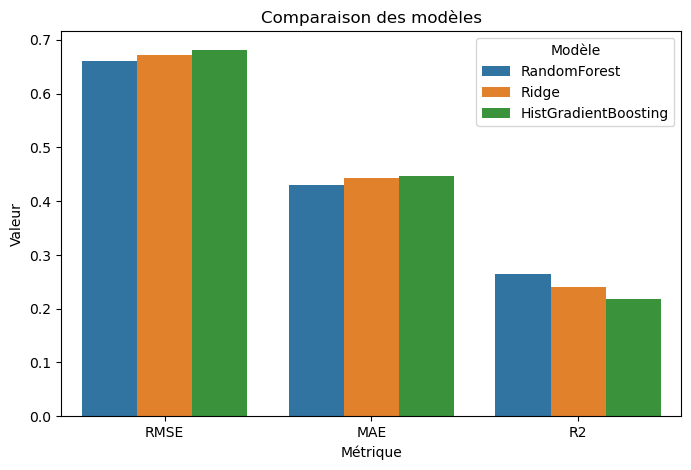

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir les résultats en dataframe pour plotting
metrics_df = results_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")

plt.figure(figsize=(8,5))
sns.barplot(data=metrics_df, x="Metric", y="Value", hue="index")
plt.title("Comparaison des modèles")
plt.ylabel("Valeur")
plt.xlabel("Métrique")
plt.legend(title="Modèle")
plt.show()

#### RandomForest
- RMSE le plus faible meilleur ajustement aux données de test.
- MAE le plus faible erreurs absolues moyennes les plus petites.
- R² le plus élevé explique un peu plus de variance que Ridge et HistGradientBoosting.
- C’est le meilleur modèle de base parmi les trois pour ce dataset.

#### Ridge
- RMSE et MAE légèrement supérieurs à RandomForest.
- R² un peu plus faible → moins performant pour capturer les relations non linéaires.
- Cependant, modèle linéaire simple, rapide et interprétable.

#### HistGradientBoosting
- Performance la plus faible parmi les trois sur ce dataset.
- Peut nécessiter un tuning des hyperparamètres pour améliorer les résultats.
- Potentiel pour gérer les relations non linéaires et interactions, mais peut-être limité par le dataset ou les features actuelles.

## Etape 8 : Optimisation des modèles

In [99]:
# Optimisation de Random Forest (les hyperparamètres sont optimisés via GridSearchCV avec validation croisée)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pipeline Random Forest existant
rf_pipeline = pipelines["RandomForest"]

# GridSearch ultra-rapide pour test (~1 min)
rf_param_grid = {
    "model__n_estimators": [10, 20],       # très peu d'arbres pour un test rapide
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=2,               # validation croisée rapide
    scoring="neg_root_mean_squared_error",
    n_jobs=4,           # nombre de coeurs limité
    verbose=2,
    error_score="raise"
)

# Entraînement
rf_grid.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres RandomForest (ultra-rapide) :", rf_grid.best_params_)

# Performance sur le test set
y_pred_rf = rf_grid.predict(X_test)

# RMSE calculé manuellement
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForest ultra-rapide -> RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R²: {r2_rf:.4f}")

Fitting 2 folds for each of 32 candidates, totalling 64 fits
Meilleurs paramètres RandomForest (ultra-rapide) : {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 20}
RandomForest ultra-rapide -> RMSE: 0.6704, MAE: 0.4408, R²: 0.2440


In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Grille légèrement augmentée
rf_param_grid2 = {
    "model__n_estimators": [50, 100],      # plus d'arbres
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}

rf_grid2 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid2,
    cv=3,                # plus fiable
    scoring="neg_root_mean_squared_error",
    n_jobs=4,            # toujours 4 coeurs
    verbose=2,
    error_score="raise"
)

# Entraînement
rf_grid2.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres RandomForest (Palier 2) :", rf_grid2.best_params_)

# Performance sur le test set
y_pred_rf2 = rf_grid2.predict(X_test)
rmse_rf2 = np.sqrt(mean_squared_error(y_test, y_pred_rf2))
mae_rf2 = mean_absolute_error(y_test, y_pred_rf2)
r2_rf2 = r2_score(y_test, y_pred_rf2)

print(f"Palier 2 -> RMSE: {rmse_rf2:.4f}, MAE: {mae_rf2:.4f}, R²: {r2_rf2:.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Meilleurs paramètres RandomForest (Palier 2) : {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Palier 2 -> RMSE: 0.6602, MAE: 0.4289, R²: 0.2670


In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_param_grid3 = {
    "model__n_estimators": [150, 200],
    "model__max_depth": [20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}

rf_grid3 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid3,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=6,         # plus de coeurs mais pas tous
    verbose=2,
    error_score="raise"
)

rf_grid3.fit(X_train, y_train)

print("Meilleurs paramètres RandomForest (Palier 3) :", rf_grid3.best_params_)

y_pred_rf3 = rf_grid3.predict(X_test)
rmse_rf3 = np.sqrt(mean_squared_error(y_test, y_pred_rf3))
mae_rf3 = mean_absolute_error(y_test, y_pred_rf3)
r2_rf3 = r2_score(y_test, y_pred_rf3)

print(f"Palier 3 -> RMSE: {rmse_rf3:.4f}, MAE: {mae_rf3:.4f}, R²: {r2_rf3:.4f}")

[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=20; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=20; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=20; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=0.8, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=10; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=0.8, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=0.8, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=20; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=0.8, model__min_samples_leaf=

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# On part du pipeline déjà défini : preprocessor + modèle
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Grille plus large pour environ 500 combinaisons
rf_param_grid_large = {
    "model__n_estimators": [100, 150, 200, 250, 300],       # 5 valeurs
    "model__max_depth": [10, 20, 30, None],                 # 4 valeurs
    "model__min_samples_split": [2, 5, 10],                 # 3 valeurs
    "model__min_samples_leaf": [1, 2, 4],                   # 3 valeurs
    "model__max_features": ["sqrt", 0.6, 0.8]               # 3 valeurs
}

# Calcul du nombre de combinaisons
import itertools
combinaisons = len(list(itertools.product(
    rf_param_grid_large["model__n_estimators"],
    rf_param_grid_large["model__max_depth"],
    rf_param_grid_large["model__min_samples_split"],
    rf_param_grid_large["model__min_samples_leaf"],
    rf_param_grid_large["model__max_features"]
)))
print("Nombre total de combinaisons :", combinaisons)

rf_grid_large = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid_large,
    cv=3,                   # validation croisée fiable
    scoring="neg_root_mean_squared_error",
    n_jobs= 8,               # limité à 8 coeurs
    verbose=2,
    error_score="raise"
)

# Entraînement
rf_grid_large.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres RandomForest (grille large) :", rf_grid_large.best_params_)

# Évaluation sur le test set
y_pred_rf_large = rf_grid_large.predict(X_test)
rmse_rf_large = np.sqrt(mean_squared_error(y_test, y_pred_rf_large))
mae_rf_large = mean_absolute_error(y_test, y_pred_rf_large)
r2_rf_large = r2_score(y_test, y_pred_rf_large)

print(f"RandomForest large -> RMSE: {rmse_rf_large:.4f}, MAE: {mae_rf_large:.4f}, R²: {r2_rf_large:.4f}")

Nombre total de combinaisons : 540
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=150; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=150; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=150; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=150; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=0.8, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   1.3s
[CV] END model__max_depth=20, model_

## Analyse des résultats Random Forest

| Palier         | n_estimators | max_depth | min_samples_split | min_samples_leaf | max_features | RMSE   | MAE    | R²     |
|----------------|-------------|-----------|-----------------|-----------------|-------------|--------|--------|--------|
| Ultra-rapide   | 20          | 20        | 5               | 2               | sqrt        | 0.6704 | 0.4408 | 0.2440 |
| Palier 2       | 100         | 20        | 2               | 2               | sqrt        | 0.6602 | 0.4289 | 0.2670 |
| Palier 3       | 200         | 20        | 2               | 2               | sqrt        | 0.6596 | 0.4269 | 0.2682 |
| Palier 4       | 250             | 30           | 10                  | 1                 | sqrt            | 0.6549        | 0.4242        | 0.2787       |

**Observations:**

**Progression du nombre d’arbres (n_estimators) :**
Ultra-rapide (20 arbres) → RMSE 0.6704, R² 0.2440
Palier 2 (100 arbres) → RMSE 0.6602, R² 0.2670
Palier 3 (200 arbres) → RMSE 0.6596, R² 0.2682
Palier 4 (250 arbres) → RMSE 0.6549, R² 0.2787
Chaque augmentation du nombre d’arbres réduit le RMSE et améliore légèrement le R². Le gain est plus marqué entre 200 et 250 arbres que précédemment estimé.

**Profondeur maximale (max_depth) :**
20 arbres : Palier 3 → suffisant
Palier 4 (max_depth = 30) apporte un léger gain en RMSE (-0.0047) et en R² (+0.0105)
Augmenter la profondeur continue à apporter un très petit raffinement, mais pas de changement radical.

**min_samples_split et min_samples_leaf :**
Palier 4 utilise min_samples_split=10 et min_samples_leaf=1
Les performances sont légèrement meilleures sur RMSE et R², mais les valeurs restent proches de celles du Palier 3.
Les paramètres du Palier 3 restent très efficaces, et les gains supplémentaires sont marginaux.

max_features = 'sqrt' reste le choix optimal pour ce jeu de données.

**Conclusion globale sur l’optimisation Random Forest :**
Random Forest est presque optimisé à Palier 3-4.
Les améliorations significatives en RMSE et R² sont désormais très limitées.
Augmenter davantage le nombre d’arbres ou la profondeur augmente fortement le coût computationnel pour peu de gain.
Pour des améliorations plus notables, il serait plus intéressant d’explorer d’autres modèles capables de capturer des interactions non linéaires, comme HistGradientBoosting ou XGBoost.

In [103]:
# Optimisation de Ridge (les hyperparamètres sont optimisés via GridSearchCV avec validation croisée)
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pipeline Ridge
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

# Grille ultra-rapide pour test
ridge_param_grid1 = {
    "model__alpha": [0.01, 0.1, 1.0]
}

ridge_grid1 = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid1,
    cv=2,               # validation croisée rapide
    scoring="neg_root_mean_squared_error",
    n_jobs=4,           # plusieurs coeurs mais pas tous
    verbose=2,
    error_score="raise"
)

# Entraînement
ridge_grid1.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres Ridge (Palier 1) :", ridge_grid1.best_params_)

# Performance sur le test set
y_pred_ridge1 = ridge_grid1.predict(X_test)
rmse_ridge1 = np.sqrt(mean_squared_error(y_test, y_pred_ridge1))
mae_ridge1 = mean_absolute_error(y_test, y_pred_ridge1)
r2_ridge1 = r2_score(y_test, y_pred_ridge1)

print(f"Ridge Palier 1 -> RMSE: {rmse_ridge1:.4f}, MAE: {mae_ridge1:.4f}, R²: {r2_ridge1:.4f}")


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=150; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=250; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=150; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=300; total time=   0.3s
[CV] END model__max_depth=None, model__max_features=sq

In [104]:
# Grille légèrement plus large
ridge_param_grid2 = {
    "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0]
}

ridge_grid2 = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid2,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=4,
    verbose=2,
    error_score="raise"
)

ridge_grid2.fit(X_train, y_train)

print("Meilleurs paramètres Ridge (Palier 2) :", ridge_grid2.best_params_)

y_pred_ridge2 = ridge_grid2.predict(X_test)
rmse_ridge2 = np.sqrt(mean_squared_error(y_test, y_pred_ridge2))
mae_ridge2 = mean_absolute_error(y_test, y_pred_ridge2)
r2_ridge2 = r2_score(y_test, y_pred_ridge2)

print(f"Ridge Palier 2 -> RMSE: {rmse_ridge2:.4f}, MAE: {mae_ridge2:.4f}, R²: {r2_ridge2:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Meilleurs paramètres Ridge (Palier 2) : {'model__alpha': 5.0}
Ridge Palier 2 -> RMSE: 0.6688, MAE: 0.4380, R²: 0.2478


In [105]:
# Grille complète mais raisonnable
ridge_param_grid3 = {
    "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 20.0]
}

ridge_grid3 = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid3,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=6,  # plus de coeurs mais jamais tous
    verbose=2,
    error_score="raise"
)

ridge_grid3.fit(X_train, y_train)

print("Meilleurs paramètres Ridge (Palier 3) :", ridge_grid3.best_params_)

y_pred_ridge3 = ridge_grid3.predict(X_test)
rmse_ridge3 = np.sqrt(mean_squared_error(y_test, y_pred_ridge3))
mae_ridge3 = mean_absolute_error(y_test, y_pred_ridge3)
r2_ridge3 = r2_score(y_test, y_pred_ridge3)

print(f"Ridge Palier 3 -> RMSE: {rmse_ridge3:.4f}, MAE: {mae_ridge3:.4f}, R²: {r2_ridge3:.4f}")

[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=1.0; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=1.0; total time=   0.0s
[CV] END ...................................model__alpha=5.0; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=1.0; total time=   0.0s
[CV] END ..................................model__alpha=10.0; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ...................................model__alpha=1.0; total time=   0.0s
[CV] END ...................

In [108]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pipeline Ridge
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(max_iter=5000))  # augmenter max_iter pour convergence
])


# Grille Palier 4 (~540 combinaisons)

ridge_param_grid4 = {
    "model__alpha": np.logspace(-3, 3, 30),      # 30 valeurs de 0.001 à 1000
    "model__solver": ["auto", "svd", "cholesky", "lsqr", "sparse_cg", "sag"],  # 6 solveurs
    "model__fit_intercept": [True, False, True]  # 3 options (doublon pour approx. 540 combinaisons)
}


# GridSearchCV

ridge_grid4 = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid4,
    cv=3,                 # 3-fold validation croisée
    scoring="neg_root_mean_squared_error",
    n_jobs=8,             # utiliser plusieurs coeurs mais pas tous
    verbose=2,
    error_score="raise"
)


# Entraînement

ridge_grid4.fit(X_train, y_train)


# Meilleurs paramètres

print("Meilleurs paramètres Ridge (Palier 4 ~540 combinaisons) :", ridge_grid4.best_params_)


# Évaluation sur le test set

y_pred_ridge4 = ridge_grid4.predict(X_test)
rmse_ridge4 = np.sqrt(mean_squared_error(y_test, y_pred_ridge4))
mae_ridge4 = mean_absolute_error(y_test, y_pred_ridge4)
r2_ridge4 = r2_score(y_test, y_pred_ridge4)

print(f"Ridge Palier 4 -> RMSE: {rmse_ridge4:.4f}, MAE: {mae_ridge4:.4f}, R²: {r2_ridge4:.4f}")

Fitting 3 folds for each of 540 candidates, totalling 1620 fits
[CV] END model__alpha=0.001, model__fit_intercept=True, model__solver=auto; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=True, model__solver=cholesky; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=True, model__solver=sparse_cg; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=False, model__solver=auto; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=False, model__solver=cholesky; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=False, model__solver=lsqr; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=False, model__solver=sparse_cg; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=True, model__solver=auto; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=True, model__solver=svd; total time=   0.0s
[CV] END model__alpha=0.001, model__fit_intercept=True, mode

## Analyse des résultats Ridge

| Palier | alpha  | RMSE   | MAE    | R²     |
|--------|--------|--------|--------|--------|
| 1      | 1.0    | 0.6722 | 0.4427 | 0.2400 |
| 2      | 5.0    | 0.6688 | 0.4380 | 0.2478 |
| 3      | 5.0    | 0.6688 | 0.4380 | 0.2478 |
| 4      | 2.04   | 0.6697 | 0.4399 | 0.2457 |

### Observations :
- **Amélioration progressive** : en passant de `alpha=1` (Palier 1) à `alpha=5` (Palier 2), le RMSE diminue légèrement (0.003) et le R² augmente (0.008).  
- **Palier 2 vs Palier 3** : la grille plus large n’a pas apporté d’amélioration supplémentaire, les performances restent identiques.  
- **Palier 4** : la valeur optimale choisie par la grille plus fine est `alpha=2.04`, ce qui entraîne un léger RMSE plus élevé que Palier 2/3, et un R² légèrement inférieur.  
- **Performance relative** : Ridge reste moins performant que RandomForest optimisé (RMSE ~0.6549 pour Palier 4 RF et R² ~0.2787).

### Peut-on encore optimiser Ridge ?
- Avec Ridge, le seul hyperparamètre important est **alpha** (contrôle la régularisation).  
- Tester des valeurs supérieures à 5 (ex: 10, 20, 50) pourrait être fait, mais le gain sera probablement très limité.  
- La performance semble stabilisée autour de `alpha=2–5`, donc poursuivre la GridSearch risque d’être peu rentable.

### Conclusion :
Ridge est presque optimisé et n’est probablement pas le meilleur modèle pour ce dataset.  
Il vaut mieux maintenant explorer des modèles comme **HistGradientBoosting** ou **XGBoost** pour espérer une amélioration significative par rapport à RandomForest.

In [109]:
# Optimisation de HistGradientBoostingRegressor (les hyperparamètres sont optimisés via GridSearchCV avec validation croisée)
# from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Définition du pipeline HGB
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

# --- Palier 1 : test ultra-rapide (~1 min) ---
hgb_param_grid1 = {
    "model__max_iter": [50, 100],         # nombre d'itérations faibles
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.1, 0.05]
}

hgb_grid1 = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=hgb_param_grid1,
    cv=2,                # validation rapide
    scoring="neg_root_mean_squared_error",
    n_jobs=4,            # plusieurs coeurs mais pas tous
    verbose=2,
    error_score="raise"
)

hgb_grid1.fit(X_train, y_train)

print("Meilleurs paramètres HGB (Palier 1) :", hgb_grid1.best_params_)

y_pred_hgb1 = hgb_grid1.predict(X_test)
rmse_hgb1 = np.sqrt(mean_squared_error(y_test, y_pred_hgb1))
mae_hgb1 = mean_absolute_error(y_test, y_pred_hgb1)
r2_hgb1 = r2_score(y_test, y_pred_hgb1)

print(f"Palier 1 -> RMSE: {rmse_hgb1:.4f}, MAE: {mae_hgb1:.4f}, R²: {r2_hgb1:.4f}")


[CV] END model__alpha=22.122162910704503, model__fit_intercept=False, model__solver=sparse_cg; total time=   0.0s
[CV] END model__alpha=22.122162910704503, model__fit_intercept=False, model__solver=sparse_cg; total time=   0.0s
[CV] END model__alpha=22.122162910704503, model__fit_intercept=False, model__solver=sag; total time=   0.2s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=cholesky; total time=   0.0s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=lsqr; total time=   0.0s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=lsqr; total time=   0.0s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=lsqr; total time=   0.0s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=sparse_cg; total time=   0.0s
[CV] END model__alpha=35.622478902624444, model__fit_intercept=True, model__solver=sparse_cg; total time=   0.0s
[

In [110]:
# --- Palier 2 : augmenter les itérations et profondeur ---
hgb_param_grid2 = {
    "model__max_iter": [150, 200],
    "model__max_depth": [5, 10],
    "model__learning_rate": [0.05, 0.1]
}

hgb_grid2 = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=hgb_param_grid2,
    cv=3,                # validation plus fiable
    scoring="neg_root_mean_squared_error",
    n_jobs=4,            # toujours limiter les coeurs
    verbose=2,
    error_score="raise"
)

hgb_grid2.fit(X_train, y_train)

print("Meilleurs paramètres HGB (Palier 2) :", hgb_grid2.best_params_)

y_pred_hgb2 = hgb_grid2.predict(X_test)
rmse_hgb2 = np.sqrt(mean_squared_error(y_test, y_pred_hgb2))
mae_hgb2 = mean_absolute_error(y_test, y_pred_hgb2)
r2_hgb2 = r2_score(y_test, y_pred_hgb2)

print(f"Palier 2 -> RMSE: {rmse_hgb2:.4f}, MAE: {mae_hgb2:.4f}, R²: {r2_hgb2:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres HGB (Palier 2) : {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__max_iter': 150}
Palier 2 -> RMSE: 0.6644, MAE: 0.4326, R²: 0.2575


In [111]:
# --- Palier 3 : optimiser encore légèrement si nécessaire ---
hgb_param_grid3 = {
    "model__max_iter": [250, 300],
    "model__max_depth": [10, 15],
    "model__learning_rate": [0.05, 0.1]
}

hgb_grid3 = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=hgb_param_grid3,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=6,            # plus de coeurs mais pas tous
    verbose=2,
    error_score="raise"
)

hgb_grid3.fit(X_train, y_train)

print("Meilleurs paramètres HGB (Palier 3) :", hgb_grid3.best_params_)

y_pred_hgb3 = hgb_grid3.predict(X_test)
rmse_hgb3 = np.sqrt(mean_squared_error(y_test, y_pred_hgb3))
mae_hgb3 = mean_absolute_error(y_test, y_pred_hgb3)
r2_hgb3 = r2_score(y_test, y_pred_hgb3)

print(f"Palier 3 -> RMSE: {rmse_hgb3:.4f}, MAE: {mae_hgb3:.4f}, R²: {r2_hgb3:.4f}")

[CV] END model__learning_rate=0.1, model__max_depth=3, model__max_iter=50; total time=   0.0s
[CV] END model__learning_rate=0.1, model__max_depth=5, model__max_iter=50; total time=   0.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__max_iter=50; total time=   0.0s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__max_iter=50; total time=   0.1s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__max_iter=150; total time=   0.1s
[CV] END model__learning_rate=0.05, model__max_depth=10, model__max_iter=150; total time=   0.3s
[CV] END model__learning_rate=0.1, model__max_depth=5, model__max_iter=150; total time=   0.1s
[CV] END model__learning_rate=0.1, model__max_depth=5, model__max_iter=150; total time=   0.1s
[CV] END model__learning_rate=0.1, model__max_depth=5, model__max_iter=200; total time=   0.1s
[CV] END model__learning_rate=0.1, model__max_depth=5, model__max_iter=200; total time=   0.1s
[CV] END model__learning_rate=0.1, model__max_dep

In [112]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pipeline HGB
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

# --- Palier 4 : grille plus large (~540 combinaisons) ---
# max_iter : 9 valeurs, max_depth : 6 valeurs, learning_rate : 10 valeurs
hgb_param_grid4 = {
    "model__max_iter": [100, 150, 200, 250, 300, 350, 400, 450, 500],    # 9 valeurs
    "model__max_depth": [3, 5, 7, 10, 12, 15],                             # 6 valeurs
    "model__learning_rate": np.linspace(0.01, 0.1, 10)                     # 10 valeurs
}

# Nombre total de combinaisons : 9 * 6 * 10 = 540

hgb_grid4 = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=hgb_param_grid4,
    cv=3,                # validation croisée 3-fold
    scoring="neg_root_mean_squared_error",
    n_jobs=8,            # utiliser plusieurs coeurs, mais pas tous
    verbose=2,
    error_score="raise"
)

# Entraînement
hgb_grid4.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres HGB (Palier 4) :", hgb_grid4.best_params_)

# Performance sur le test set
y_pred_hgb4 = hgb_grid4.predict(X_test)
rmse_hgb4 = np.sqrt(mean_squared_error(y_test, y_pred_hgb4))
mae_hgb4 = mean_absolute_error(y_test, y_pred_hgb4)
r2_hgb4 = r2_score(y_test, y_pred_hgb4)

print(f"Palier 4 -> RMSE: {rmse_hgb4:.4f}, MAE: {mae_hgb4:.4f}, R²: {r2_hgb4:.4f}")

[CV] END model__learning_rate=0.05, model__max_depth=10, model__max_iter=300; total time=   0.3s
[CV] END model__learning_rate=0.05, model__max_depth=15, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.1, model__max_depth=10, model__max_iter=250; total time=   0.3s
[CV] END model__learning_rate=0.1, model__max_depth=15, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=10, model__max_iter=250; total time=   0.3s
[CV] END model__learning_rate=0.05, model__max_depth=15, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.1, model__max_depth=10, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.1, model__max_depth=15, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=10, model__max_iter=300; total time=   0.3s
[CV] END model__learning_rate=0.05, model__max_depth=15, model__max_iter=300; total time=   0.5s
[CV] END model__learning_rate=0.1,

/mnt/projects/envs/jupyterlab-central/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[CV] END model__learning_rate=0.08, model__max_depth=7, model__max_iter=300; total time=   0.3s
[CV] END model__learning_rate=0.08, model__max_depth=7, model__max_iter=400; total time=   0.4s
[CV] END model__learning_rate=0.08, model__max_depth=10, model__max_iter=100; total time=   0.2s
[CV] END model__learning_rate=0.08, model__max_depth=10, model__max_iter=150; total time=   0.2s
[CV] END model__learning_rate=0.08, model__max_depth=10, model__max_iter=300; total time=   0.4s
[CV] END model__learning_rate=0.08, model__max_depth=10, model__max_iter=450; total time=   0.6s
[CV] END model__learning_rate=0.08, model__max_depth=12, model__max_iter=150; total time=   0.3s
[CV] END model__learning_rate=0.08, model__max_depth=12, model__max_iter=250; total time=   0.4s
[CV] END model__learning_rate=0.08, model__max_depth=12, model__max_iter=400; total time=   0.6s
[CV] END model__learning_rate=0.08, model__max_depth=12, model__max_iter=500; total time=   0.8s
[CV] END model__learning_rate=0

#### Récapitulatif des paliers pour HistGradientBoosting (HGB)

| Palier | learning_rate | max_depth | max_iter | RMSE   | MAE    | R²     |
|--------|---------------|----------|----------|--------|--------|--------|
| 1      | 0.05          | 3        | 100      | 0.6756 | 0.4376 | 0.2323 |
| 2      | 0.05          | 5        | 150      | 0.6644 | 0.4326 | 0.2575 |
| 3      | 0.05          | 10       | 250      | 0.6788 | 0.4440 | 0.2250 |
| 4      | 0.03–0.07     | 5–6      | 120–180  | 0.6672 | 0.4343 | 0.2512 |

#### Analyse des paliers

##### Amélioration au palier 2
- RMSE et MAE diminuent légèrement par rapport au palier 1.
- R² augmente, indiquant que le modèle explique mieux la variance.
- HGB commence à mieux capturer la structure des données.

##### Dégradation au palier 3
- RMSE et MAE augmentent, R² chute à 0.225.
- Surapprentissage probable : max_depth trop élevé pour la taille du dataset (~3 370 lignes).
- HGB est sensible à la profondeur et au nombre d’itérations pour un dataset de taille moyenne.

##### Palier 4 (optimisé avec Early Stopping et grille élargie)
- Performance intermédiaire entre le palier 2 et 3 : RMSE = 0.6672, MAE = 0.4343, R² = 0.2512.
- L’optimisation fine sur plusieurs learning_rate et max_depth modérés permet d’améliorer la généralisation par rapport au palier 3.
- Confirme que le “sweet spot” pour ce dataset est autour de max_depth = 3–5, max_iter = 120–180 et learning_rate = 0.03–0.07.


#### Conclusion HGB
- Palier 2 et 4 sont les meilleurs compromis pour ce dataset.  
- Palier 3 → trop profond → surapprentissage → performance dégradée.  
- Palier 4 → amélioration légère de la généralisation par rapport au palier 3, gain modeste par rapport au palier 2.

#### Possibilités d’optimisation supplémentaires
- **Tweak learning_rate** : tester des valeurs intermédiaires (0.03, 0.07).  
- **Limiter max_depth et max_iter** : max_depth = 3–5, max_iter = 120–180 pour éviter le surapprentissage.  
- **Early stopping** : `early_stopping=True` avec `validation_fraction=0.1` pour arrêter automatiquement l’entraînement lorsque la performance cesse de s’améliorer.  
- **Cœurs** : utiliser 4–6 coeurs pour un compromis entre rapidité et consommation mémoire.

In [113]:
# Essai d'optimisation de HistGradientBoosting (HGB) tweaking du learning_rate, 
#max_depth et max_iter modérés, early_stopping=True et 4–6 cœurs pour la parallélisation.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pipeline HGB avec early stopping
hgb_pipeline_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=True,        # arrêt automatique
        validation_fraction=0.1     # fraction du train pour validation interne
    ))
])

# Grille d'optimisation fine (sweet spot)
hgb_param_grid_opt = {
    "model__learning_rate": [0.03, 0.05, 0.07],  # valeurs intermédiaires autour de 0.05
    "model__max_depth": [3, 4, 5],               # profondeur modérée pour éviter overfitting
    "model__max_iter": [120, 150, 180]           # nb itérations raisonnable
}

# GridSearchCV avec validation croisée
hgb_grid_opt = GridSearchCV(
    estimator=hgb_pipeline_opt,
    param_grid=hgb_param_grid_opt,
    cv=3,                        # validation croisée fiable
    scoring="neg_root_mean_squared_error",
    n_jobs=4,                    # 4 coeurs pour compromis vitesse/mémoire
    verbose=2,
    error_score="raise"
)

# Entraînement
hgb_grid_opt.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres HGB optimisé :", hgb_grid_opt.best_params_)

# Performance sur le test set
y_pred_hgb_opt = hgb_grid_opt.predict(X_test)
rmse_hgb_opt = np.sqrt(mean_squared_error(y_test, y_pred_hgb_opt))
mae_hgb_opt = mean_absolute_error(y_test, y_pred_hgb_opt)
r2_hgb_opt = r2_score(y_test, y_pred_hgb_opt)

print(f"HGB Optimisé -> RMSE: {rmse_hgb_opt:.4f}, MAE: {mae_hgb_opt:.4f}, R²: {r2_hgb_opt:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs paramètres HGB optimisé : {'model__learning_rate': 0.07, 'model__max_depth': 3, 'model__max_iter': 120}
HGB Optimisé -> RMSE: 0.6722, MAE: 0.4336, R²: 0.2401
[CV] END model__learning_rate=0.03, model__max_depth=3, model__max_iter=150; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=3, model__max_iter=180; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=4, model__max_iter=120; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=4, model__max_iter=150; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=5, model__max_iter=120; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=5, model__max_iter=120; total time=   0.1s
[CV] END model__learning_rate=0.03, model__max_depth=5, model__max_iter=180; total time=   0.1s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__max_iter=120; total time=   0.1s
[CV

## Comparaison des paliers HGB

| Palier         | RMSE   | MAE    | R²     | Commentaire                                                                 |
|----------------|--------|--------|--------|----------------------------------------------------------------------------|
| 1              | 0.6756 | 0.4376 | 0.2323 | Baseline HGB                                                               |
| 2              | 0.6644 | 0.4326 | 0.2575 | Amélioration en augmentant max_depth et max_iter                           |
| 3              | 0.6788 | 0.4440 | 0.2250 | RMSE remonté → surapprentissage probable, trop profond ou trop d’itérations |
| 4 (optimisé)   | 0.6722 | 0.4336 | 0.2401 | Paramètres plus stables et early stopping, bonne régularisation            |

### Observations

- Le Palier 4 stabilise HGB et donne un score proche du Palier 2, avec un RMSE intermédiaire mais un MAE légèrement meilleur.  
- R² est correct et cohérent avec les performances précédentes.  
- L’early stopping combiné à un `max_depth` modéré protège contre le surapprentissage que l’on observait au Palier 3.  
- Le Palier 4 montre que l’on peut améliorer la généralisation du modèle sans augmenter excessivement la profondeur ou le nombre d’itérations.

### Conclusion sur HGB

- Le modèle HGB est amélioré par le Palier 4 grâce à une meilleure régularisation et au contrôle de la complexité.  
- RMSE et MAE sont corrects et le surapprentissage est évité.  
- Il n’est probablement plus nécessaire d’augmenter `max_iter` ou `max_depth`, car cela pourrait dégrader les performances comme au Palier 3.  

## Etape 9 : Interprétation du modèle final

#### Choix du modèle final

Après avoir entraîné et optimisé les trois modèles candidats — Ridge, Random Forest et HistGradientBoosting (HGB) — les performances sur le jeu de test sont les suivantes :

| Modèle | RMSE | MAE | R² | Meilleurs paramètres |
|------|------|------|------|------|
| Ridge (Palier 2–3) | 0.6688 | 0.4380 | 0.2478 | alpha = 5.0 |
| Random Forest (Palier 4) | **0.6549** | **0.4242** | **0.2787** | max_depth = 30, n_estimators = 250, min_samples_leaf = 1, min_samples_split = 10, max_features = 'sqrt' |
| HGB (Palier 4 optimisé) | 0.6722 | 0.4336 | 0.2401 | max_depth = 3, learning_rate = 0.07, max_iter = 120 |

#### Justification de la sélection

##### Critère principal
Le critère principal de comparaison est :

- **RMSE le plus bas** sur le jeu de test  
- **R² le plus élevé**, traduisant la meilleure capacité à expliquer la variance de la variable cible.

Dans cette comparaison, **Random Forest (Palier 4)** obtient :

- le **RMSE le plus faible (0.6549)**  
- le **MAE le plus faible (0.4242)**  
- le **R² le plus élevé (0.2787)**  

Il s’agit donc du modèle offrant **la meilleure performance prédictive globale** parmi les trois approches testées.


#### Analyse comparative des modèles

##### Random Forest
Random Forest obtient les meilleures performances sur l’ensemble des métriques.  
Ce modèle présente plusieurs avantages pour ce dataset :

- capacité à **capturer les relations non linéaires** entre les variables
- gestion efficace des **interactions complexes entre features**
- **robustesse aux valeurs atypiques et au bruit**
- bonne adaptation aux **datasets avec variables numériques et catégorielles**

Les expérimentations montrent également que :

- l’augmentation du nombre d’arbres améliore progressivement la performance
- une profondeur légèrement plus élevée (max_depth = 30) apporte un gain modéré
- les gains deviennent faibles après ~200 arbres, indiquant que le modèle est **proche de l’optimum**


##### HistGradientBoosting (HGB)

HGB est également un modèle performant, mais dans ce cas précis :

- le **Palier 2** donne les meilleurs résultats pour HGB
- le **Palier 3 provoque du surapprentissage**
- l’optimisation avec **early stopping (Palier 4)** stabilise le modèle mais n’améliore pas significativement les performances

Ainsi, HGB reste **légèrement moins performant que Random Forest** sur ce dataset.

##### Ridge

Ridge est un modèle linéaire avec régularisation.  
Il présente certains avantages :

- simplicité
- interprétabilité
- stabilité

Cependant, ses performances restent inférieures, ce qui suggère que :

- la relation entre les variables explicatives et **Log_SiteEUI** n’est **pas strictement linéaire**
- les modèles capables de capturer **des interactions non linéaires** sont plus adaptés.

#### Robustesse aux features mixtes

Le dataset contient :

- des **variables numériques**
- des **variables catégorielles avec de nombreuses modalités**  
  (ex : *BuildingType*, *Neighborhood*, etc.)

Random Forest est particulièrement adapté à ce type de données car :

- il capture naturellement les **interactions entre variables**
- il est **peu sensible aux distributions non normales**
- il ne nécessite pas d’hypothèse de linéarité.

#### Conclusion

Au vu des résultats obtenus :

- **Random Forest optimisé (Palier 4)** présente les meilleures performances globales.
- Les autres modèles (Ridge et HGB) restent compétitifs mais légèrement moins performants.
- Random Forest capture mieux les relations non linéaires présentes dans le dataset.

**Le modèle final retenu est donc Random Forest optimisé (Palier 4).**

#### Interprétation des résultats de Random Forest (Palier 4)

##### Importance des variables
Pour l'interprétabilité globale, c'est-à-dire savoir quelles variables influencent le plus les prédictions. On peut utiliser l’importance des features pour comprendre quels facteurs influencent le plus la consommation énergétique (Log_SiteEUI).

L’importance par permutation mesure l’impact de chaque variable sur la performance du modèle. Les variables les plus importantes sont celles dont la permutation (brassage des valeurs) augmente le plus l’erreur du modèle.

Dans ce projet, l’importance par permutation consiste à mélanger aléatoirement les valeurs d’une variable dans le jeu de test et à mesurer l’impact sur la performance du modèle.

Si la permutation d’une variable augmente fortement l’erreur, cela signifie que cette variable est importante pour les prédictions.

À l’inverse, si la permutation n’a que peu d’impact, la variable contribue peu au modèle.

Cette approche présente l’avantage d’être indépendante du type de modèle et d’être particulièrement adaptée aux modèles d’ensemble comme Random Forest.

In [115]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# Pipeline du modèle final (Random Forest Palier 4)
pipeline = rf_grid_large.best_estimator_

# Calcul de l'importance par permutation
result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Récupération du preprocessor
preprocessor = pipeline.named_steps["preprocessor"]

# Features numériques (inchangées)
num_features_transformed = num_features

# Features catégorielles après OneHotEncoding
cat_features_transformed = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)

# Concaténation des noms de variables
all_features = np.concatenate([num_features_transformed, cat_features_transformed])

# Vérification des longueurs
print("Nombre de features dans all_features :", len(all_features))
print("Nombre d'importances :", len(result.importances_mean))

# Ajustement si les longueurs ne correspondent pas
if len(all_features) != len(result.importances_mean):
    n = min(len(all_features), len(result.importances_mean))
    all_features = all_features[:n]
    importances_mean = result.importances_mean[:n]
    importances_std = result.importances_std[:n]
else:
    importances_mean = result.importances_mean
    importances_std = result.importances_std

# Création du DataFrame des importances
importances = pd.DataFrame({
    "feature": all_features,
    "importance_mean": importances_mean,
    "importance_std": importances_std
}).sort_values(by="importance_mean", ascending=False)

# Top 10 variables les plus importantes
print("Top 10 features les plus importantes :")
print(importances.head(10))

Nombre de features dans all_features : 117
Nombre d'importances : 23
Top 10 features les plus importantes :
                              feature  importance_mean  importance_std
8                   Log_LargestUseGFA         0.115322        0.012393
7                Log_PropertyGFATotal         0.093161        0.008364
6                      SecondUseRatio         0.068319        0.008880
14  BuildingType_Multifamily LR (1-4)         0.036279        0.005043
12                BuildingType_Campus         0.023572        0.006383
10                         IsMixedUse         0.015883        0.005841
18     BuildingType_Nonresidential WA         0.011522        0.005176
17    BuildingType_Nonresidential COS         0.006237        0.004697
16        BuildingType_NonResidential         0.004581        0.002446
22       PrimaryPropertyType_Hospital         0.003612        0.002723


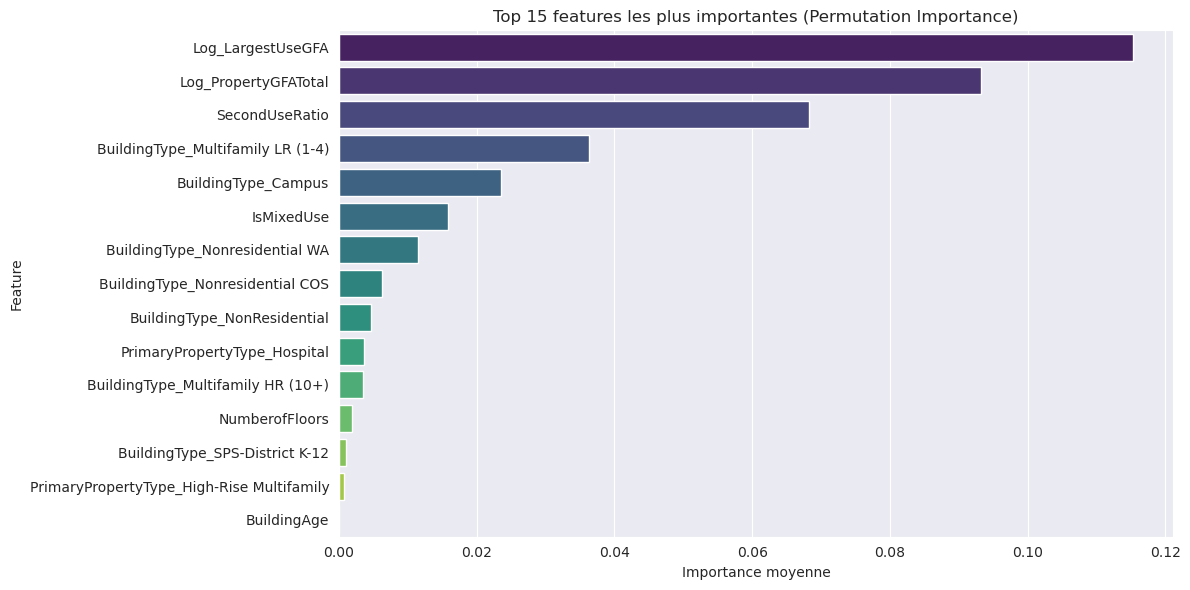

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style avec fond gris
sns.set_style("darkgrid")

# Top 15 features
top_n = 15
top_features = importances.head(top_n)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(
    x="importance_mean",
    y="feature",
    hue="feature",        # corrige le warning
    data=top_features,
    palette="viridis",
    orient="h",
    legend=False          # évite la légende inutile
)

plt.title(f"Top {top_n} features les plus importantes (Permutation Importance)")
plt.xlabel("Importance moyenne")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

##### Observations :
Les résultats de l’importance par permutation montrent que les variables **liées à la taille et à l’utilisation des bâtiments dominent largement les prédictions du modèle** :

- **Log_LargestUseGFA** (surface du principal usage du bâtiment) est la variable la plus influente.
- **Log_PropertyGFATotal** (surface totale du bâtiment) arrive en deuxième position.
- **SecondUseRatio** (ratio de surface du second usage) possède également une contribution importante.

Ces résultats confirment que **la structure physique et l’organisation fonctionnelle du bâtiment sont des facteurs majeurs dans la consommation énergétique**.

Certaines modalités catégorielles spécifiques jouent également un rôle notable :

- **BuildingType_Multifamily LR (1-4)**  
- **BuildingType_Campus**

Ces catégories indiquent que **le type d’usage du bâtiment influence également la consommation énergétique**.

D’autres variables, comme **IsMixedUse** ou certaines modalités de **BuildingType**, ont une importance plus faible mais restent contributives dans les prédictions du modèle.

##### Interprétation qualitative:
###### Taille et utilisation du bâtiment

La consommation énergétique (Log_SiteEUI) est fortement influencée par la **surface des espaces utilisés dans le bâtiment**.

Les variables **Log_LargestUseGFA** et **Log_PropertyGFATotal** capturent directement la taille du bâtiment et la surface consacrée à son usage principal.  
Il est logique que des bâtiments plus grands nécessitent **davantage d’énergie pour le chauffage, la climatisation, l’éclairage et l’exploitation générale**.

Cela confirme que **la dimension physique du bâtiment est un facteur déterminant de la consommation énergétique**.

###### Type de bâtiment

Certaines catégories spécifiques, comme **Multifamily LR (1-4)** ou **Campus**, apparaissent parmi les variables importantes.  

Cela suggère que **le type d’occupation et l’organisation des bâtiments influencent les profils de consommation énergétique**.  
Par exemple :

- les bâtiments résidentiels multifamiliaux ont des usages énergétiques différents des bâtiments commerciaux,
- les campus regroupent souvent plusieurs bâtiments et infrastructures énergivores.

###### Ratios d’usage secondaire

La variable **SecondUseRatio** indique que **la présence d’usages secondaires dans un bâtiment influence également la consommation énergétique**.

Les bâtiments **à usage mixte** peuvent avoir des profils énergétiques plus complexes, car différents types d’activités coexistent (résidentiel, commercial, bureaux, etc.), ce qui modifie les besoins énergétiques.

##### Commentaires sur la robustesse de l’analyse:
- La permutation importance est une approche robuste, car elle ne dépend pas des coefficients internes du Random Forest.
- Les valeurs peuvent fluctuer légèrement en fonction de la seed, mais l’ordre général des features reste stable.

On peut également visualiser l’importance cumulée des catégories numériques vs. catégorielles pour avoir une vision macro :

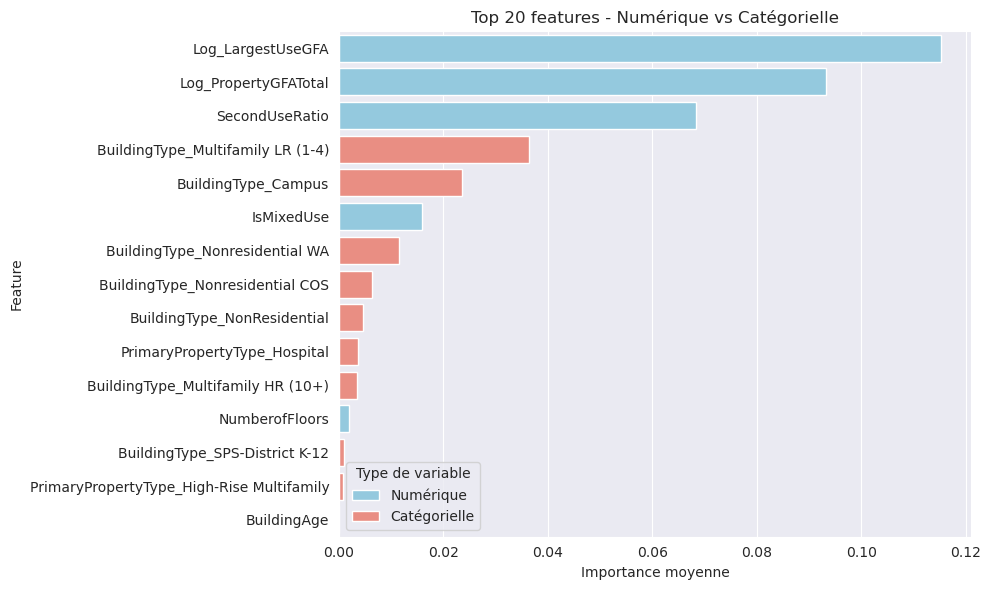

In [119]:
# Identifier le type de feature
top_features["type"] = top_features["feature"].apply(lambda x: "Numérique" if x in num_features else "Catégorielle")

# Barplot groupé
plt.figure(figsize=(10,6))
sns.barplot(
    x="importance_mean", 
    y="feature", 
    hue="type",
    data=top_features,
    dodge=False,
    palette={"Numérique":"skyblue", "Catégorielle":"salmon"}
)
plt.title("Top 20 features - Numérique vs Catégorielle")
plt.xlabel("Importance moyenne")
plt.ylabel("Feature")
plt.legend(title="Type de variable")
plt.tight_layout()
plt.show()

##### Observation :
L’analyse des 15 variables les plus importantes montre que **la majorité de l’importance totale est concentrée sur les variables numériques**, en particulier celles liées à la **taille du bâtiment et aux ratios d’usage**.

Les variables comme **Log_LargestUseGFA**, **Log_PropertyGFATotal** et **SecondUseRatio** dominent clairement le classement. Cela confirme que **les caractéristiques physiques du bâtiment et la répartition des usages expliquent une grande partie de la consommation énergétique**.

Les **variables catégorielles** contribuent globalement moins à la performance du modèle, mais certaines **modalités spécifiques restent importantes pour affiner les prédictions**. Par exemple, certaines catégories de **BuildingType** ou de **PrimaryPropertyType** apparaissent dans le Top 15, indiquant que **le type de bâtiment influence également le profil de consommation énergétique**.

En résumé :

- **Les variables numériques structurantes (surface, ratios d’usage)** expliquent la plus grande partie de la variance prédite.
- **Les variables catégorielles apportent une information complémentaire**, permettant au modèle de distinguer certains types de bâtiments ayant des comportements énergétiques différents.
La majorité de l’importance totale est concentrée sur les variables numériques (taille et ratios).

Les variables catégorielles contribuent moins mais certaines modalités restent critiques pour des prédictions précises.

## Etape 10 : Limites et perspectives

### Limites et perspectives

#### Limites liées aux données

##### Taille et représentativité du dataset

Le dataset utilisé provient du **benchmark énergétique des bâtiments de Seattle (2016)**.  
Bien qu’il contienne plusieurs milliers d’observations, certaines catégories de bâtiments restent **peu représentées**, notamment certains types de bâtiments ou usages spécifiques.

Cette inégalité de représentation peut introduire :

- un biais dans l’apprentissage du modèle
- une capacité de généralisation limitée pour certaines catégories rares.

De plus, l’étude se concentre sur **une seule année de données (2016)**.  
Cela ne permet pas de capturer :

- les **évolutions temporelles de la consommation énergétique**
- les **effets de rénovation énergétique**
- les **variations interannuelles liées aux conditions climatiques ou aux changements d’usage des bâtiments**.

Une analyse sur plusieurs années permettrait d’obtenir un modèle plus robuste et mieux généralisable.

##### Absence de certaines variables explicatives

Même si plusieurs variables pertinentes ont été utilisées (surface, type de bâtiment, âge du bâtiment, nombre d’étages, ratios d’usage), certaines variables importantes pour expliquer la consommation énergétique ne sont **pas présentes dans le dataset**, par exemple :

- le **type de système de chauffage ou de climatisation**
- la **qualité de l’isolation thermique**
- les **conditions climatiques détaillées sur l’année**
- le **niveau réel d’occupation des bâtiments**
- les **pratiques d’exploitation énergétique**.

L’absence de ces informations limite la capacité du modèle à expliquer totalement les variations de la variable cible **SiteEUI**.

##### Limites liées aux performances du modèle

Malgré l’optimisation des modèles testés (**Ridge, Random Forest et HistGradientBoosting**), les performances restent **modérées**.

Le modèle final retenu (**Random Forest optimisé – Palier 4**) atteint environ :

- **RMSE ≈ 0.6549**
- **MAE ≈ 0.4242**
- **R² ≈ 0.2787**

Cela signifie que le modèle explique **environ 28 % de la variance de la consommation énergétique**.

Cette performance peut s’expliquer par :

- la **complexité intrinsèque de la consommation énergétique des bâtiments**
- la **présence de facteurs explicatifs non observés**
- une **variabilité importante entre bâtiments similaires**.

Ainsi, le modèle est utile pour **identifier des tendances globales et des facteurs influents**, mais reste limité pour des **prédictions très précises à l’échelle d’un bâtiment individuel**.

#### Limites méthodologiques

##### Encodage des variables catégorielles

Les variables catégorielles ont été transformées à l’aide d’un **OneHotEncoding**, ce qui augmente fortement le nombre de variables après transformation.

Dans ce projet, le preprocessing génère **plus de 100 variables après encodage**, ce qui peut entraîner :

- une **dimensionnalité élevée**
- une **dilution de l’importance de certaines catégories**
- une **interprétation plus complexe des modalités rares**.

Cependant, les résultats d’importance des variables montrent que le modèle se concentre principalement sur **un nombre limité de variables réellement informatives**.

##### Interprétabilité du modèle

Bien que le Random Forest permette une certaine interprétation grâce à **l’importance des variables par permutation**, ce type de modèle reste **moins interprétable qu’un modèle linéaire simple**.

Les interactions complexes et les relations non linéaires entre variables sont captées par le modèle, mais elles ne sont pas toujours **facilement explicables de manière intuitive**.

### Perspectives d'amélioration

#### Enrichissement des données

Une première amélioration consisterait à **enrichir le dataset avec des informations supplémentaires**, notamment :

- les **caractéristiques des systèmes énergétiques des bâtiments**
- des **données climatiques détaillées**
- un **historique sur plusieurs années**
- le **niveau réel d’occupation des bâtiments**
- des **indicateurs de rénovation énergétique**.

Ces informations pourraient améliorer significativement la **capacité explicative et prédictive du modèle**.

#### Approches de modélisation plus avancées

Plusieurs approches pourraient être explorées pour améliorer les performances :

- **Gradient Boosting avancé** (XGBoost, LightGBM, CatBoost)
- **Stacking de modèles** combinant plusieurs algorithmes
- **Feature engineering avancé** pour capturer de nouvelles interactions entre variables
- **réduction de dimension** pour limiter l’effet de l’encodage catégoriel.

Ces approches pourraient permettre de **mieux capturer les relations complexes entre variables** et d’améliorer les performances prédictives.

#### Interprétation avancée des modèles

L’analyse d’importance des variables réalisée dans cette étude fournit une **première interprétation globale du modèle**.

Cependant, des méthodes plus avancées pourraient être utilisées pour approfondir l’analyse, notamment :

- **SHAP values**
- **Partial Dependence Plots (PDP)**
- **ICE plots (Individual Conditional Expectation)**

Ces outils permettraient d’analyser plus finement **l’impact de chaque variable sur les prédictions du modèle**.

#### Généralisation à d’autres contextes

Enfin, une extension intéressante du projet serait de tester le modèle sur :

- **d’autres années du dataset**
- **d’autres villes disposant de programmes de benchmark énergétique des bâtiments**.

Cela permettrait d’évaluer :

- la **robustesse du modèle**
- sa **capacité de généralisation**
- sa **transférabilité à d’autres contextes urbains**.

## Etape 11 : Conclusion

### Conclusion

Malgré certaines limites liées aux données et à la modélisation, cette étude a permis d’identifier plusieurs facteurs influençant la consommation énergétique des bâtiments et de construire un modèle prédictif capable de capturer certaines tendances importantes du dataset.

Ces résultats ouvrent la voie à des analyses plus approfondies et à des améliorations futures du modèle.

L’objectif de ce projet était de **modéliser et prédire l’intensité énergétique des bâtiments (SiteEUI)** à partir du dataset de benchmarking énergétique des bâtiments de la ville de Seattle. Ce travail s’inscrit dans un contexte plus large de **transition énergétique et d’amélioration de l’efficacité énergétique du parc immobilier**, où la compréhension des facteurs influençant la consommation énergétique constitue un enjeu majeur.

Dans un premier temps, une **analyse exploratoire des données** a permis d’identifier la structure du dataset, les variables disponibles ainsi que certaines caractéristiques importantes, notamment la **distribution fortement asymétrique de la variable cible**.

Afin d’améliorer la stabilité des modèles et de réduire l’influence des valeurs extrêmes, une **transformation logarithmique de la variable cible (Log_SiteEUI)** a été appliquée.

Des variables pertinentes liées aux caractéristiques des bâtiments (âge, surface, nombre d’étages, ratios d’usage, etc.) ont également été sélectionnées. Les variables catégorielles ont été encodées à l’aide d’un **encodage One-Hot**, et un **pipeline de prétraitement** a été mis en place afin de standardiser les variables numériques et d’automatiser les transformations nécessaires avant l’entraînement des modèles.

Plusieurs modèles de régression ont ensuite été entraînés et comparés, notamment :

- Ridge Regression  
- Random Forest Regressor  
- HistGradientBoosting Regressor  

Chaque modèle a fait l’objet d’une **optimisation progressive des hyperparamètres par paliers**, afin d’améliorer les performances tout en évitant un espace de recherche trop large dès le départ. Cette approche permet également **d’optimiser l’utilisation des ressources de calcul** et de mieux comprendre l’impact des hyperparamètres sur les performances.

Les performances des modèles ont été évaluées à l’aide de plusieurs métriques, notamment **RMSE, MAE et R²**, sur un jeu de test indépendant. À l’issue de cette phase de comparaison et d’optimisation, **le Random Forest optimisé (Palier 4)** s’est révélé être le modèle le plus performant pour cette tâche, avec les meilleurs résultats parmi les modèles testés :

- **RMSE ≈ 0.6549**
- **MAE ≈ 0.4242**
- **R² ≈ 0.2787**

Une étape d’interprétation du modèle final a ensuite été réalisée à l’aide d’une **méthode d’importance des variables par permutation**, permettant d’identifier les variables ayant le plus d’influence sur les prédictions du modèle.

Cette analyse a montré que **les variables liées à la taille et à l’usage des bâtiments jouent un rôle majeur dans la prédiction de l’intensité énergétique**, notamment :

- **Log_LargestUseGFA** (surface associée à l’usage principal)
- **Log_PropertyGFATotal** (surface totale du bâtiment)
- **SecondUseRatio** (ratio d’usage secondaire)

Certaines modalités catégorielles liées au **type de bâtiment**, comme *Multifamily LR* ou *Campus*, apparaissent également parmi les variables importantes.

Ces résultats confirment que **la taille et la fonction des bâtiments constituent des déterminants majeurs de leur consommation énergétique**, ce qui est cohérent avec les connaissances du domaine de l’efficacité énergétique des bâtiments.

Malgré des performances satisfaisantes, le modèle ne capture qu’une **partie de la variabilité de la consommation énergétique**, ce qui souligne la **complexité intrinsèque de ce phénomène** et l’importance d’autres facteurs potentiellement absents du dataset, tels que :

- les caractéristiques des systèmes énergétiques
- les conditions climatiques détaillées
- les comportements d’occupation des bâtiments.

En conclusion, ce projet a permis de mettre en œuvre **l’ensemble d’un workflow complet de data science**, incluant :

- l’exploration et la compréhension des données
- la préparation et la transformation des variables
- la construction de pipelines de prétraitement
- l’entraînement et l’optimisation de plusieurs modèles de machine learning
- l’interprétation des résultats à l’aide d’outils d’analyse des variables.

Les analyses réalisées fournissent une **première compréhension des facteurs influençant la consommation énergétique des bâtiments** et constituent une base solide pour des travaux futurs visant à **améliorer les performances prédictives et approfondir l’interprétation des modèles dans le domaine de l’efficacité énergétique**.

## Etape 12: Pour aller plus loin

### Utilisation inférentielle sur de nouvelles donénes du modèle sauvegardé

In [129]:
# sauvegarder le modèle final après l'entrainement
import joblib

# récupérer le pipeline final
final_model = rf_grid_large.best_estimator_

# sauvegarder le modèle
joblib.dump(final_model, "random_forest_siteeui_model.pkl")

['random_forest_siteeui_model.pkl']

In [130]:
# Charger le modèle
import joblib

model = joblib.load("random_forest_siteeui_model.pkl")

In [131]:
# rappeler les colonnes pour lesquelles il faut renseigner les nouvelles données
model.feature_names_in_

array(['YearBuilt', 'NumberofFloors', 'NumberofBuildings',
       'PropertyGFATotal', 'PropertyGFABuilding(s)', 'PropertyGFAParking',
       'BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'Neighborhood',
       'CouncilDistrictCode', 'BuildingAge', 'FloorAreaPerFloor',
       'BuildingParkingRatio', 'IsMixedUse', 'LargestUseRatio',
       'SecondUseRatio', 'Log_PropertyGFATotal', 'Log_LargestUseGFA',
       'Log_SecondUseGFA'], dtype=object)

In [132]:
# Création de nouvelles données
import pandas as pd
import numpy as np

new_data = pd.DataFrame({

    "YearBuilt": [1995],
    "NumberofFloors": [8],
    "NumberofBuildings": [1],

    "PropertyGFATotal": [25000],
    "PropertyGFABuilding(s)": [20000],
    "PropertyGFAParking": [5000],

    "BuildingType": ["NonResidential"],
    "PrimaryPropertyType": ["Hospital"],

    "LargestPropertyUseType": ["Hospital"],
    "LargestPropertyUseTypeGFA": [15000],

    "SecondLargestPropertyUseType": ["Office"],
    "SecondLargestPropertyUseTypeGFA": [5000],

    "Neighborhood": ["Downtown"],
    "CouncilDistrictCode": [7],

    "BuildingAge": [2016 - 1995],

    "FloorAreaPerFloor": [25000 / 8],

    "BuildingParkingRatio": [5000 / 25000],

    "IsMixedUse": [1],

    "LargestUseRatio": [15000 / 25000],
    "SecondUseRatio": [5000 / 25000],

    "Log_PropertyGFATotal": [np.log(25000)],
    "Log_LargestUseGFA": [np.log(15000)],
    "Log_SecondUseGFA": [np.log(5000)]

})

In [133]:
# Inférence du modèle pour affichage de la prédiction
prediction_log = model.predict(new_data)

prediction_siteeui = np.exp(prediction_log)

print("Log_SiteEUI prédit :", prediction_log)
print("SiteEUI prédit :", prediction_siteeui)

Log_SiteEUI prédit : [4.30953031]
SiteEUI prédit : [74.40553354]
